In [2]:
import pandas as pd

import matplotlib.pyplot as plt
df = pd.read_csv('train.csv')
calender_events =  pd.read_csv('calendar_events.csv')
df = df.merge( calender_events, on='date', how = 'left')
df['date'] = pd.to_datetime(df['date'])
df




,store_id,store_name,date,revenue,event
0,0,All Stores,2011-01-29,204126.52,NaN
1,0,All Stores,2011-01-30,197426.42,NaN
2,0,All Stores,2011-01-31,144267.27,NaN
3,0,All Stores,2011-02-01,151903.00,NaN
4,0,All Stores,2011-02-02,117399.88,NaN
...,...,...,...,...,...
18761,10,Wisconsin – Badger Crossing,2015-09-26,25689.55,NaN
18762,10,Wisconsin – Badger Crossing,2015-09-27,26557.53,NaN
18763,10,Wisconsin – Badger Crossing,2015-09-28,19067.53,NaN
18764,10,Wisconsin – Badger Crossing,2015-09-29,16467.95,NaN


In [3]:
df.groupby('store_id')['store_name'].last()

store_id
0                      All Stores
1       California – Sunset Plaza
2         California – Ocean View
3       California – Golden Hills
4     California – Redwood Center
5          Texas – Lone Star Mall
6        Texas – Riverwalk Market
7           Texas – Alamo Heights
8         Wisconsin – Maple Grove
9      Wisconsin – Lakeview Plaza
10    Wisconsin – Badger Crossing
Name: store_name, dtype: object

Text(0.5, 1.0, 'Events Averaged Revenue')

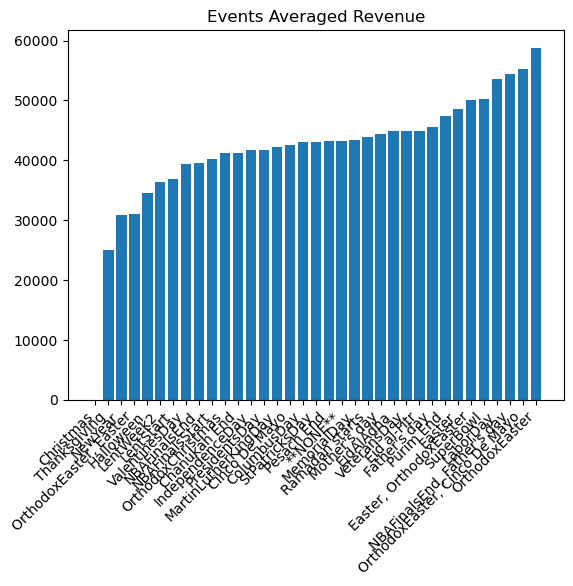

In [ ]:
calendar = df.fillna('**NONE**').groupby('event')['revenue'].mean().sort_values()
plt.bar(calendar.index, calendar)
plt.xticks(rotation=45, ha='right')
plt.title('Events Averaged Revenue')


# Feature Engineering 

In [3]:
import pandas as pd
import numpy as np

def engineer_multioutput_features(df, horizon_days=92, is_training=True):
    """
    Generates features and a multi-column target matrix for a 
    MultiOutputRegressor LightGBM model.
    
    Parameters:
    - is_training: If True, drops the last 92 days so the model has complete targets to learn from.
                   If False, keeps the last days so you can forecast the true future.
    """
    # 0. Ensure chronological order (Critical for shift/rolling)
    df = df.sort_values(['store_id', 'date']).reset_index(drop=True)
    
    # ==========================================
    # 1. Deterministic Calendar Features (State at Day T)
    # ==========================================
    df['day_of_week'] = df['date'].dt.dayofweek.astype('category')
    df['day_of_month'] = df['date'].dt.day.astype('category')
    df['month'] = df['date'].dt.month.astype('category')
    
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Cyclical Encodings for day of year
    day_of_year = df['date'].dt.dayofyear
    df['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)

    # Fill NaN events with a placeholder
    df['event'] = df['event'].fillna('None')
    df['is_event'] = (df['event'] != 'None').astype(int)
    df['is_christmas'] = (df['event'] == 'Christmas').astype(int)
    
    # ==========================================
    # 2. Target-Safe Autoregressive Features (Recent Lags)
    # ==========================================
    lags = [1, 2, 7, 14, 28, 364]
    for lag in lags:
        df[f'revenue_lag_{lag}'] = df.groupby('store_id')['revenue'].shift(lag)

    # ==========================================
    # 3. Momentum & Volatility (Recent Rolling Windows)
    # ==========================================
    windows = [7, 28]
    for window in windows:
        df[f'rolling_mean_{window}d'] = df.groupby('store_id')['revenue'].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
        df[f'rolling_std_{window}d'] = df.groupby('store_id')['revenue'].transform(
            lambda x: x.rolling(window=window, min_periods=1).std()
        )
        df[f'rolling_max_{window}d'] = df.groupby('store_id')['revenue'].transform(
            lambda x: x.rolling(window=window, min_periods=1).max()
        )

    # ==========================================
    # 4. Target Matrix Generation (Y_1 to Y_92)
    # ==========================================
    target_cols = []
    for lead in range(1, horizon_days + 1):
        col_name = f'target_day_{lead}'
        df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
        target_cols.append(col_name)

    # ==========================================
    # 5. Model Preparations & Cleaning
    # ==========================================
    df['store_id'] = df['store_id'].astype('category')
    
    # ALWAYS drop the beginning of the dataset where historical lags are missing
    df_cleaned = df.dropna(subset=[f'revenue_lag_{max(lags)}']).reset_index(drop=True)
    
    # CONDITIONALLY drop the end of the dataset
    if is_training:
        # Drop rows where the future hasn't happened yet
        df_cleaned = df_cleaned.dropna(subset=[f'target_day_{horizon_days}']).reset_index(drop=True)
    
    return df_cleaned, target_cols

In [4]:
def plot_results(pred, real, pred_target_name ='revenue'):
    plt.plot(pred['date'], pred[pred_target_name], label = 'prediction')
    plt.plot(real['date'], real['revenue'], label = 'real')
    plt.legend()
    plt.show()
    pass
    
    

In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

def train_multi_output_tweedie(df, target_cols, horizon_days=92):
    """
    Trains a MultiOutputRegressor wrapped LightGBM model per store using Tweedie loss.
    Includes a plot of the first 92-day forecast slice vs actuals for visual validation.
    """
    drop_cols = ['date', 'revenue', 'store_name', 'event'] + target_cols
    feature_cols = [col for col in df.columns if col not in drop_cols]
    
    store_results = {}
    
    for store in df['store_id'].unique():
        print(f"--- Training Multi-Output Tweedie Model for Store: {store} ---")
        store_df = df[df['store_id'] == store].copy()
        
        # Chronological Split
        max_date = store_df['date'].max()
        split_date = max_date - pd.Timedelta(days=horizon_days)
        
        train_mask = store_df['date'] <= split_date
        val_mask = store_df['date'] > split_date
        
        X_train = store_df.loc[train_mask, feature_cols]
        y_train = store_df.loc[train_mask, target_cols]
        
        X_val = store_df.loc[val_mask, feature_cols]
        y_val = store_df.loc[val_mask, target_cols]
        
        # Skip if validation set is empty
        if len(X_val) == 0:
            print(f"Skipping Store {store}: Not enough data for validation split.")
            continue
        
        # Enforce categorical dtypes
        for col in ['day_of_week']:
            if col in X_train.columns:
                X_train[col] = X_train[col].astype('category')
                X_val[col] = X_val[col].astype('category')

        base_model = lgb.LGBMRegressor(
            objective='tweedie',
            tweedie_variance_power=1.5,
            boosting_type='gbdt',
            learning_rate=0.05,
            num_leaves=31,
            n_estimators=150,
            feature_fraction=0.8,
            random_state=42,
            verbose=-1
        )
        
        multi_output_model = MultiOutputRegressor(base_model)
        multi_output_model.fit(X_train, y_train)
        preds = multi_output_model.predict(X_val)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        print(f"Store {store} Multi-Output Matrix RMSE: {rmse:.2f}\n")
        
        # ==========================================
        # VISUALIZATION BLOCK
        # ==========================================
        # Extract the very first row (Day T) of the validation set
        # This shows a continuous 92-day trajectory
        single_actual = y_val.iloc[0, :].values
        single_pred = preds[0, :]
        
        plt.figure(figsize=(12, 5))
        days_axis = np.arange(1, horizon_days + 1)
        
        plt.plot(days_axis, single_actual, label='Actual Revenue', marker='.', color='black', alpha=0.6)
        plt.plot(days_axis, single_pred, label='Predicted Revenue (Tweedie)', marker='', color='blue', linewidth=2)
        
        plt.title(f"Store {store}: 92-Day Forecast vs Actuals (From first day of Validation)")
        plt.xlabel("Days into the Future (1 to 92)")
        plt.ylabel("Revenue")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
        # ==========================================
        
        # Save results
        store_results[store] = {}
        store_results[store]['preds'] = preds
        store_results[store]['real'] = y_val
        store_results[store]['model'] = multi_output_model
        
    return store_results

In [6]:
def plot_results(pred, real, pred_target_name ='revenue'):
    plt.plot(pred['date'], pred[pred_target_name], label = 'prediction')
    plt.plot(real['date'], real['revenue'], label = 'real')
    plt.legend()
    plt.show()
    pass
    
    

/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

--- Training Multi-Output Tweedie Model for Store: 0 ---
Store 0 Multi-Output Matrix RMSE: 23948.46



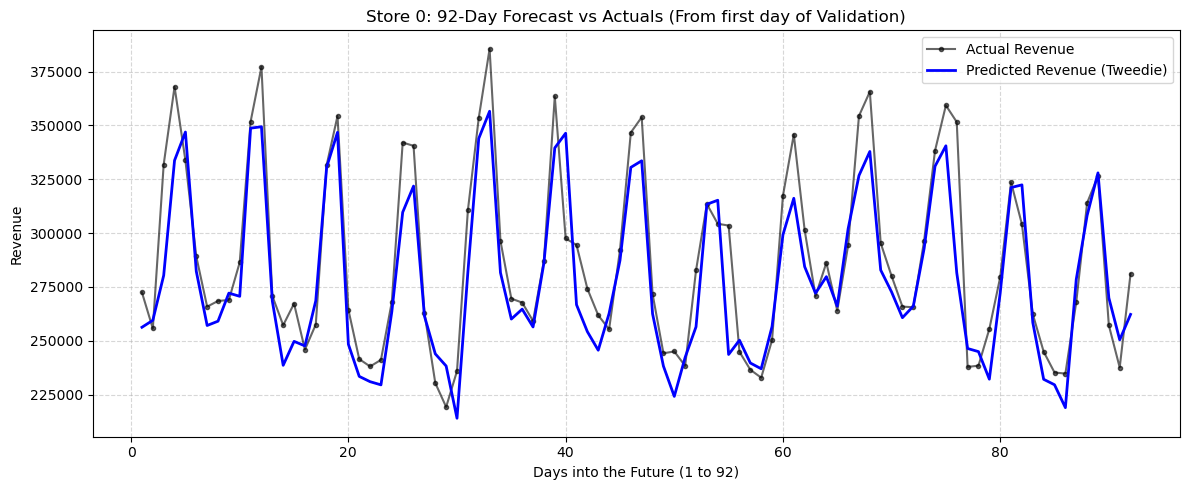

--- Training Multi-Output Tweedie Model for Store: 1 ---
Store 1 Multi-Output Matrix RMSE: 3203.25



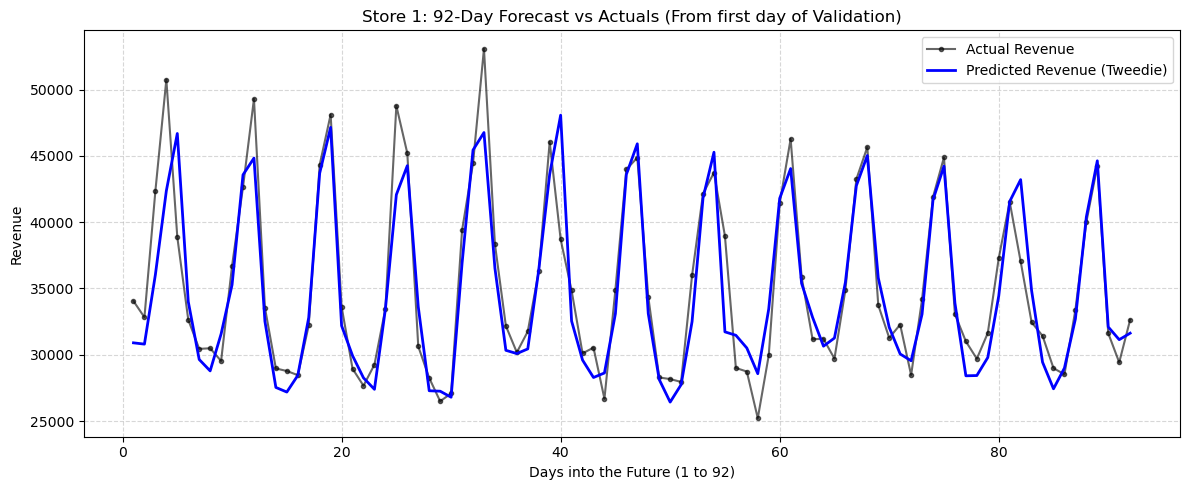

--- Training Multi-Output Tweedie Model for Store: 2 ---
Store 2 Multi-Output Matrix RMSE: 7125.66



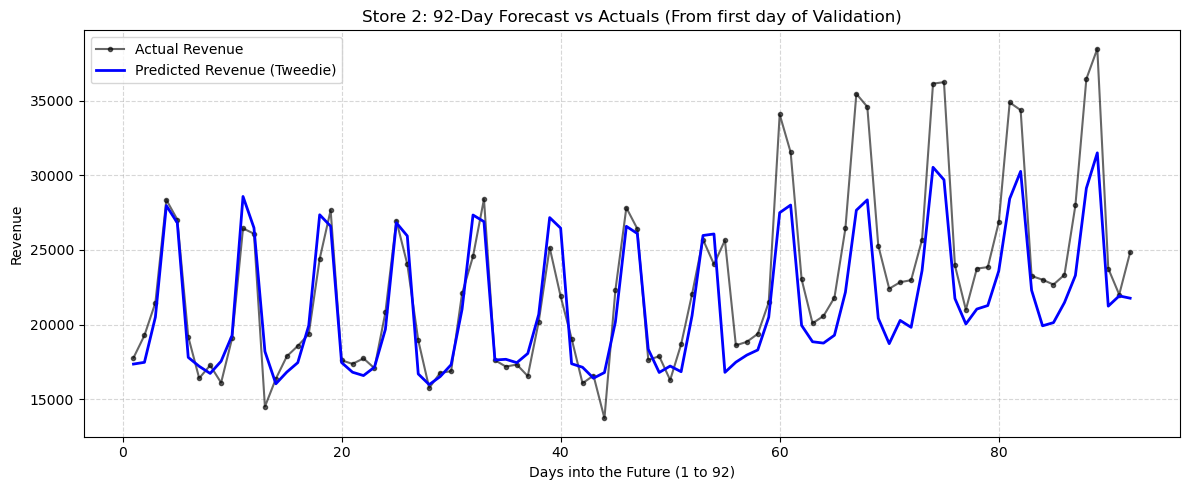

--- Training Multi-Output Tweedie Model for Store: 3 ---
Store 3 Multi-Output Matrix RMSE: 3753.23



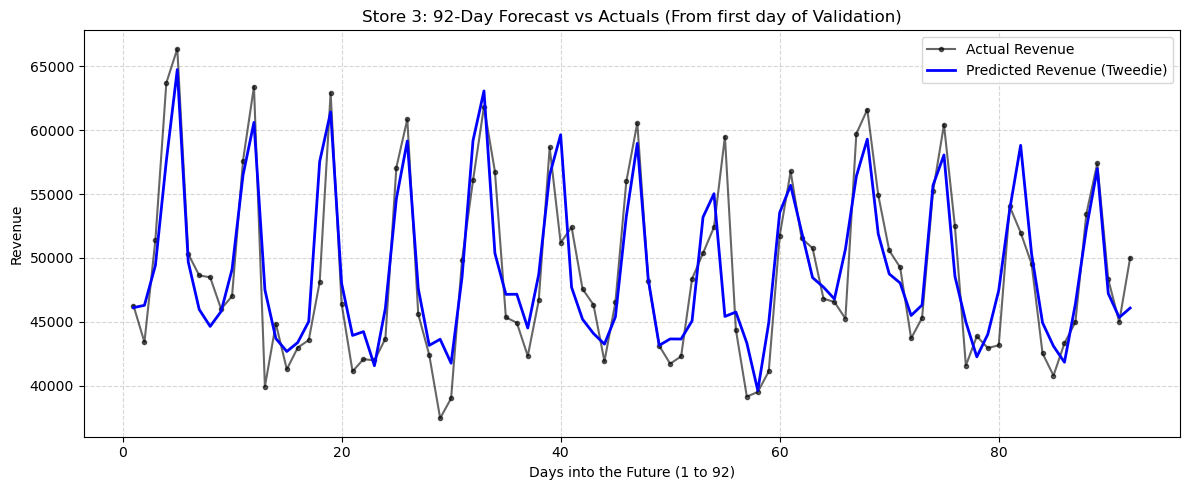

--- Training Multi-Output Tweedie Model for Store: 4 ---
Store 4 Multi-Output Matrix RMSE: 1571.14



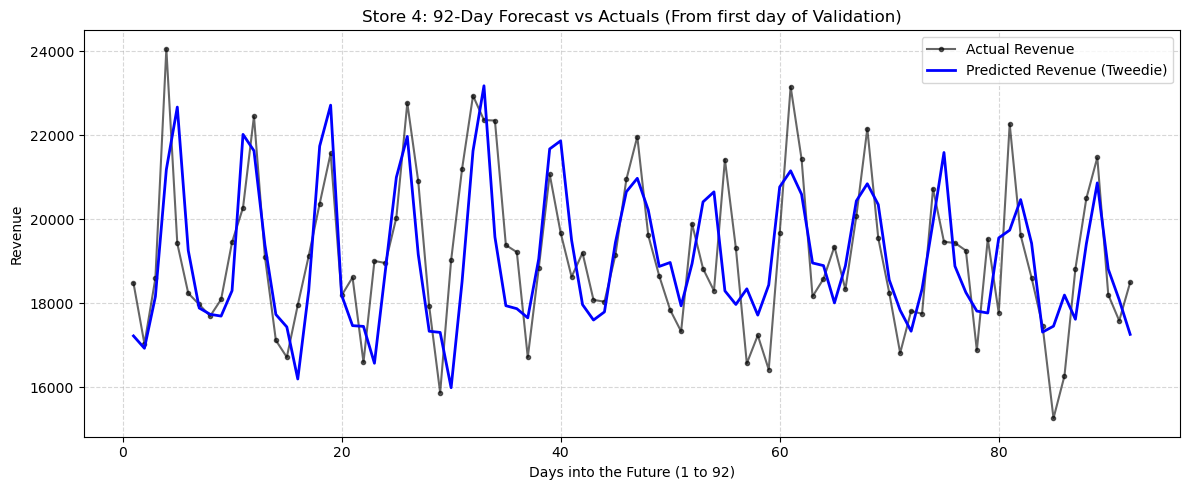

--- Training Multi-Output Tweedie Model for Store: 5 ---
Store 5 Multi-Output Matrix RMSE: 2658.08



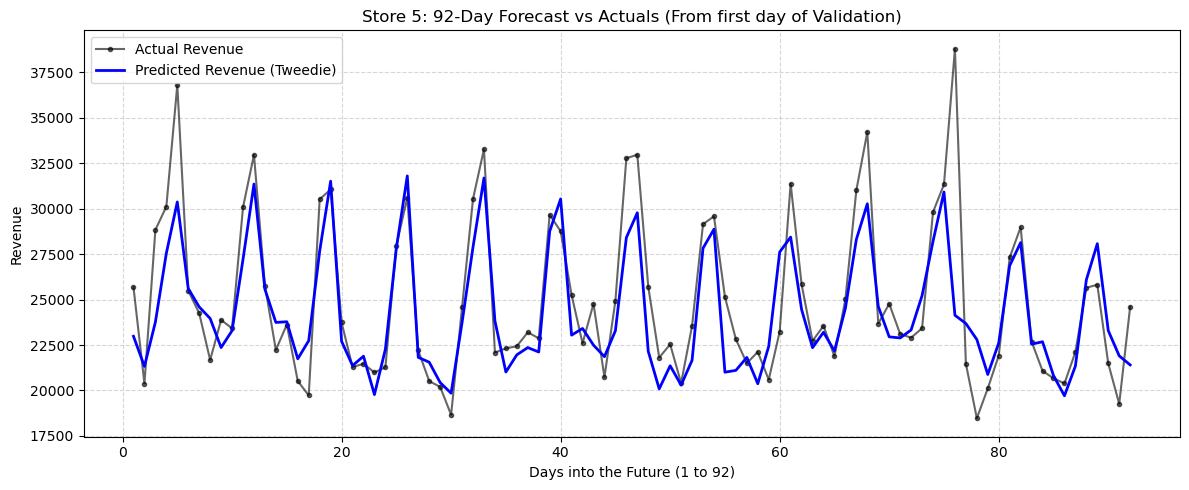

--- Training Multi-Output Tweedie Model for Store: 6 ---
Store 6 Multi-Output Matrix RMSE: 3195.94



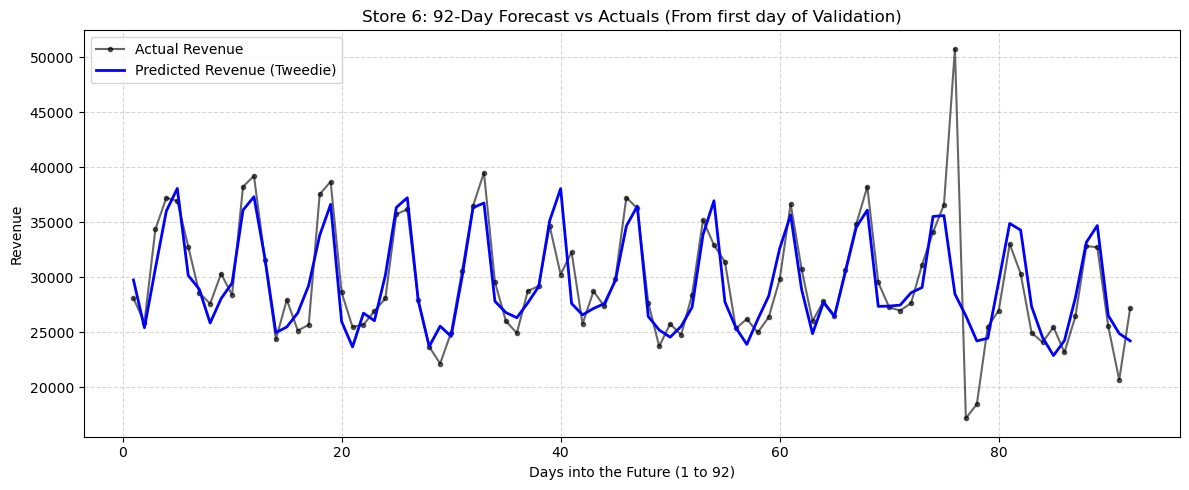

--- Training Multi-Output Tweedie Model for Store: 7 ---
Store 7 Multi-Output Matrix RMSE: 3797.25



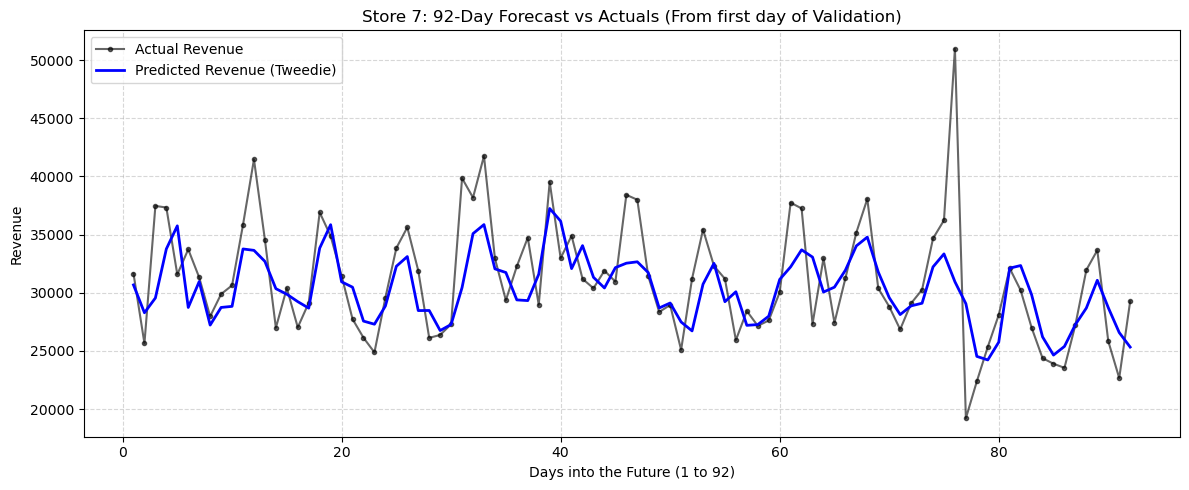

--- Training Multi-Output Tweedie Model for Store: 8 ---
Store 8 Multi-Output Matrix RMSE: 2780.31



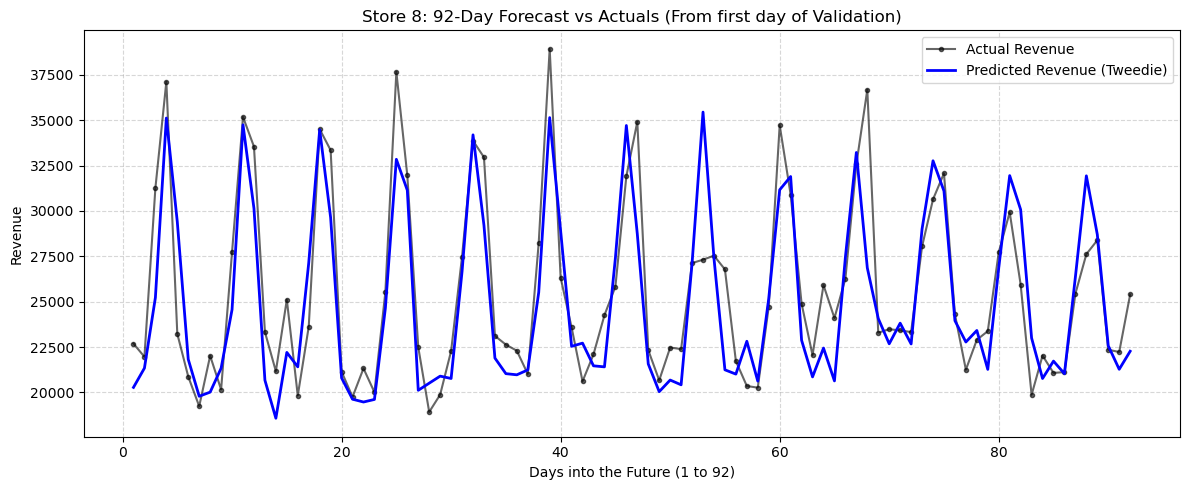

--- Training Multi-Output Tweedie Model for Store: 9 ---
Store 9 Multi-Output Matrix RMSE: 2666.79



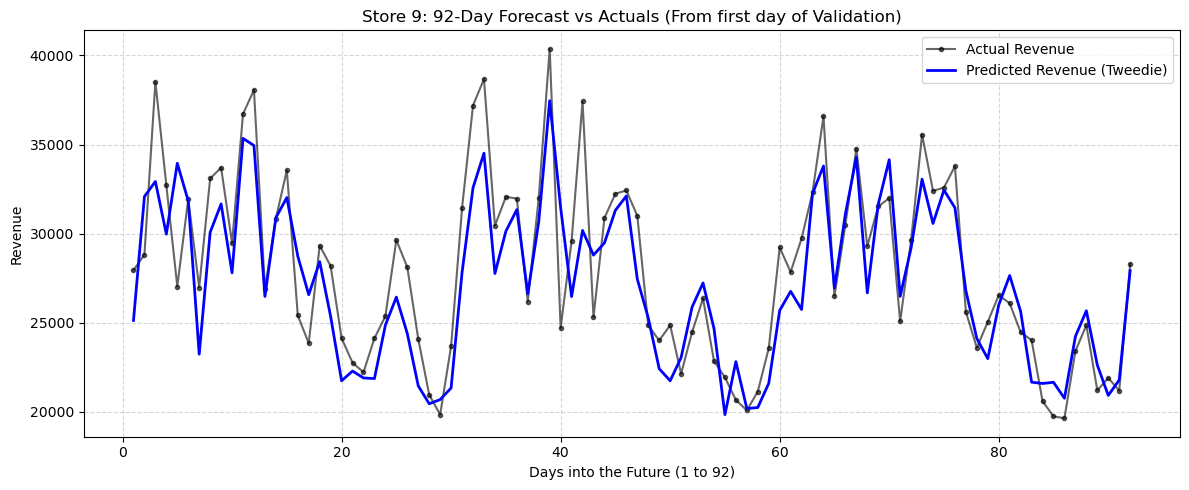

--- Training Multi-Output Tweedie Model for Store: 10 ---
Store 10 Multi-Output Matrix RMSE: 2408.96



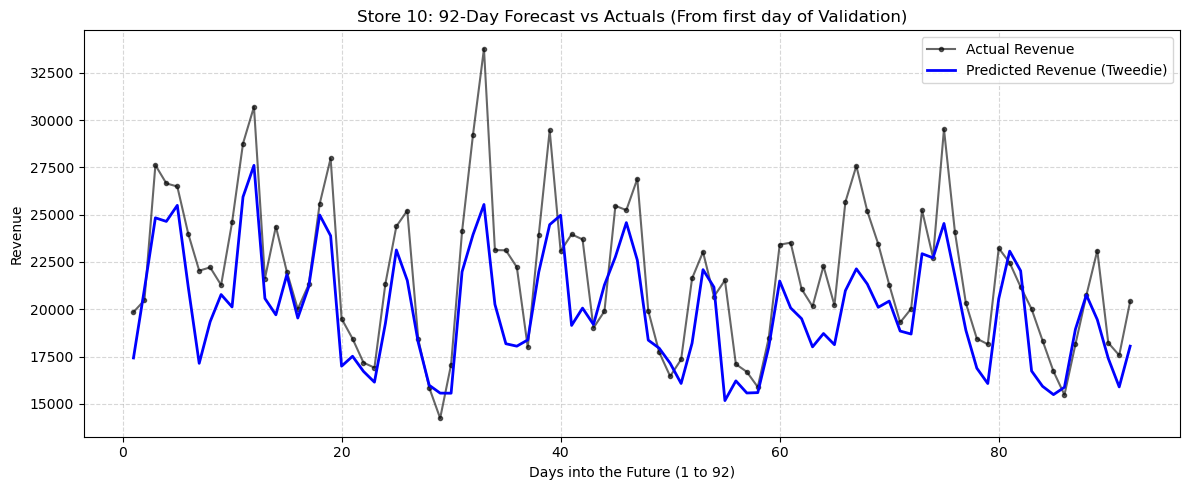

In [7]:
df_mof, targets = engineer_multioutput_features(df)
results = train_multi_output_tweedie(df_mof, targets)



In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor

def generate_production_forecast(df, target_cols, horizon_days=92):
    """
    Trains on ALL available historical data and predicts the true future 92 days.
    Returns a clean, decipherable DataFrame of future dates and revenues per store.
    """
    # Ensure chronological order
    df = df.sort_values(['store_id', 'date']).reset_index(drop=True)
    
    # Identify features
    drop_cols = ['date', 'revenue', 'store_name', 'event'] + target_cols
    feature_cols = [col for col in df.columns if col not in drop_cols]
    
    all_store_forecasts = []
    
    unique_stores = df['store_id'].unique()
    print(f"Generating true future forecasts for {len(unique_stores)} stores...\n")
    
    for store in unique_stores:
        print(f"Training & Forecasting Store: {store}")
        store_df = df[df['store_id'] == store].copy()
        
        # ==========================================
        # 1. Split Training Data vs "Today"
        # ==========================================
        # Training Set: Rows where we ACTUALLY have the future 92 days to learn from.
        # We drop rows where the furthest target (target_day_92) is NaN.
        train_df = store_df.dropna(subset=[target_cols[-1]]).copy()
        
        # Inference Set: The absolute last chronological day in the dataset.
        # This row has NaNs for the future targets, which is exactly what we want to predict!
        inference_row = store_df.tail(1).copy()
        last_known_date = inference_row['date'].iloc[0]
        
        # ==========================================
        # 2. Prepare X and Y Matrices
        # ==========================================
        X_train = train_df[feature_cols]
        Y_train = train_df[target_cols]
        
        X_infer = inference_row[feature_cols]
        
        # Enforce categorical datatypes
        for col in ['day_of_week']:
            if col in feature_cols:
                X_train[col] = X_train[col].astype('category')
                X_infer[col] = X_infer[col].astype('category')
                
        # ==========================================
        # 3. Train on 100% of Known Data
        # ==========================================
        # We cannot use early stopping because there is no validation set!
        # We lock in the n_estimators to a stable number (e.g., 150 or whatever 
        # your best_iteration was during your validation phase).
        base_model = lgb.LGBMRegressor(
            objective='tweedie',
            tweedie_variance_power=1.5,
            boosting_type='gbdt',
            learning_rate=0.05,
            num_leaves=31,
            n_estimators=150, 
            feature_fraction=0.8,
            random_state=42,
            verbose=-1
        )
        
        multi_output_model = MultiOutputRegressor(base_model)
        multi_output_model.fit(X_train, Y_train)
        
        # ==========================================
        # 4. Predict the True Future
        # ==========================================
        # Predict returns a 2D matrix. We slice [0] to get the 1D array of 92 values.
        future_preds = multi_output_model.predict(X_infer)[0]
        
        # Prevent Tweedie from occasionally outputting a negative fraction
        future_preds = np.clip(future_preds, a_min=0, a_max=None)
        
        # ==========================================
        # 5. Format the Output
        # ==========================================
        # Generate the exact calendar dates for the next 92 days
        future_dates = pd.date_range(start=last_known_date + pd.Timedelta(days=1), periods=horizon_days)
        
        store_forecast = pd.DataFrame({
            'store_id': store,
            'date': future_dates,
            'predicted_revenue': future_preds
        })
        
        all_store_forecasts.append(store_forecast)
        
    # Combine everything into one clean master table
    final_forecast_df = pd.concat(all_store_forecasts, ignore_index=True)
    
    print("\n✅ All forecasts generated successfully.")
    return final_forecast_df

# ==========================================
# EXECUTION
# ==========================================
# 1. Ensure your feature generation didn't drop the last row!
# raw_features_df, target_columns = engineer_multioutput_features(raw_data)

# 2. Run the production function
# future_predictions = generate_production_forecast(raw_features_df, target_columns)

# 3. View the results
# print(future_predictions.head(10))

In [10]:
df_mof, targets = engineer_multioutput_features(df, is_training=False)
res = generate_production_forecast(df_mof, targets, horizon_days=92)

/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/1654717432.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually 

Generating true future forecasts for 11 stores...

Training & Forecasting Store: 0
Training & Forecasting Store: 1


/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_infer[col] = X_infer[col].astype('category')


Training & Forecasting Store: 2


/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_infer[col] = X_infer[col].astype('category')


...

Training & Forecasting Store: 9


/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_infer[col] = X_infer[col].astype('category')


Training & Forecasting Store: 10


/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype('category')
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_76952/4120957178.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_infer[col] = X_infer[col].astype('category')



✅ All forecasts generated successfully.


In [40]:
res['id'] = res['store_id'].astype(str)+ '_' + res['date'].astype(str).str.replace('-', '')
res = res.rename(columns={'predicted_revenue': 'prediction'})


is_christmas = (res['date'].dt.month == 12) & (res['date'].dt.day == 25)

# 3. Use .loc to assign exactly 0 to the 'predicted_revenue' column for those days
res.loc[is_christmas, 'prediction'] = 0


res[['id', 'prediction']].iloc[:,:2].set_index('id').to_csv('best_multiOutReg.csv')

# Claude Optimization

In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error


# ==============================================================================
# PART 1: FEATURE ENGINEERING
# Key improvements:
#   [A] Peak-aware lag features (historical max/spikes around same calendar period)
#   [B] Shorter lags (3, 5) to capture sharp local momentum
#   [C] Longer rolling windows (90d) to model seasonal baseline
#   [D] Exponential Weighted Mean — reacts faster to recent changes than rolling mean
#   [E] Lead event flags: "is a big event coming in the next N days?"
#   [F] YoY ratio feature — directly encodes seasonal amplitude
#   [G] Volatility ratio — tells the model how "spiky" recent behaviour has been
# ==============================================================================

def engineer_multioutput_features(df, horizon_days=92, is_training=True):
    """
    Generates features and a multi-column target matrix.
    All features remain target-safe (only use data available at forecast time T).
    """
    df = df.sort_values(['store_id', 'date']).reset_index(drop=True)

    # ------------------------------------------------------------------
    # 1. Calendar Features
    # ------------------------------------------------------------------
    df['day_of_week']  = df['date'].dt.dayofweek.astype('category')
    df['day_of_month'] = df['date'].dt.day.astype('category')
    df['month']        = df['date'].dt.month.astype('category')
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['quarter']      = df['date'].dt.quarter.astype('category')
    df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)

    # Cyclical encodings
    day_of_year = df['date'].dt.dayofyear
    df['day_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    df['day_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

    # ------------------------------------------------------------------
    # 2. Event Features
    #    [E] Lead flags: gives the model warning that a spike is COMING
    # ------------------------------------------------------------------
    df['event']        = df['event'].fillna('None')
    df['is_event']     = (df['event'] != 'None').astype(int)
    df['is_christmas'] = (df['event'] == 'Christmas').astype(int)

    # Flag if a major event falls within the next 7 / 14 days
    # (still target-safe: we know the calendar in advance)
    df['event_in_7d'] = df.groupby('store_id')['is_event'].transform(
        lambda x: x.shift(-1).rolling(7, min_periods=1).max()   # peek ahead in calendar
    ).fillna(0).astype(int)
    df['event_in_14d'] = df.groupby('store_id')['is_event'].transform(
        lambda x: x.shift(-1).rolling(14, min_periods=1).max()
    ).fillna(0).astype(int)

    # ------------------------------------------------------------------
    # 3. Lag Features — Added short lags [3, 5] for sharper local momentum
    # ------------------------------------------------------------------
    lags = [1, 2, 3, 5, 7, 14, 28, 364]
    for lag in lags:
        df[f'revenue_lag_{lag}'] = df.groupby('store_id')['revenue'].shift(lag)

    # ------------------------------------------------------------------
    # 4. Rolling Window Features
    #    [C] Added 90d window for seasonal baseline
    #    [D] EWM — reacts faster to recent spikes than a plain mean
    #    [G] Volatility ratio — spike detection
    # ------------------------------------------------------------------
    windows = [7, 28, 90]
    for window in windows:
        grp = df.groupby('store_id')['revenue']
        df[f'rolling_mean_{window}d'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f'rolling_std_{window}d'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )
        df[f'rolling_max_{window}d'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).max()
        )
        df[f'rolling_min_{window}d'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).min()
        )

    # [D] Exponential Weighted Mean (span=7 and span=28)
    for span in [7, 28]:
        df[f'ewm_mean_{span}'] = df.groupby('store_id')['revenue'].transform(
            lambda x: x.ewm(span=span, adjust=False).mean()
        )

    # [G] Volatility ratio: how spiky is recent behaviour vs the longer window?
    df['volatility_ratio_7_28'] = (
        df['rolling_std_7d'] / (df['rolling_std_28d'] + 1e-6)
    )

    # [A] Peak-aware: same-week-of-year max from prior years
    df['same_week_max_ly'] = df.groupby(['store_id', 'week_of_year'])['revenue'].transform(
        lambda x: x.shift(1).expanding().max()  # max seen in prior years for this week
    )
    df['same_week_mean_ly'] = df.groupby(['store_id', 'week_of_year'])['revenue'].transform(
        lambda x: x.shift(1).expanding().mean()
    )

    # [F] YoY ratio: current 7d mean vs same 7d window one year ago
    df['yoy_ratio'] = (
        df['rolling_mean_7d'] /
        (df['revenue_lag_364'].rolling(7, min_periods=1).mean() + 1e-6)
    )

    # Momentum: short-term mean vs longer-term mean
    df['momentum_7_28']  = df['rolling_mean_7d']  / (df['rolling_mean_28d']  + 1e-6)
    df['momentum_7_90']  = df['rolling_mean_7d']  / (df['rolling_mean_90d']  + 1e-6)
    df['momentum_28_90'] = df['rolling_mean_28d'] / (df['rolling_mean_90d']  + 1e-6)

    # ------------------------------------------------------------------
    # 5. Target Matrix
    # ------------------------------------------------------------------
    target_cols = []
    for lead in range(1, horizon_days + 1):
        col_name = f'target_day_{lead}'
        df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
        target_cols.append(col_name)

    # ------------------------------------------------------------------
    # 6. Cleaning
    # ------------------------------------------------------------------
    df['store_id'] = df['store_id'].astype('category')
    df_cleaned = df.dropna(subset=[f'revenue_lag_{max(lags)}']).reset_index(drop=True)

    if is_training:
        df_cleaned = df_cleaned.dropna(subset=[f'target_day_{horizon_days}']).reset_index(drop=True)

    return df_cleaned, target_cols


# ==============================================================================
# PART 2: MODEL TRAINING
# Key improvements:
#   [H] Quantile blending: train p50 (median) + p90 for peaks — blend them
#   [I] Stronger hyperparameters: more leaves, more trees, min_child_samples
#   [J] Direct LightGBM API with early stopping instead of sklearn wrapper
#       → eliminates overhead of 92 separate sklearn fits
#   [K] Post-processing: scale predicted peaks toward historical max amplitude
# ==============================================================================

def train_multi_output_lgbm(df, target_cols, horizon_days=92):
    """
    Trains per-store LightGBM models with two objectives (median + p90)
    and blends them to recover peak amplitude.

    Returns store_results dict with predictions, actuals, and models.
    """
    drop_cols = ['date', 'revenue', 'store_name', 'event'] + target_cols
    feature_cols = [col for col in df.columns if col not in drop_cols]

    # [I] Stronger base hyperparameters
    BASE_PARAMS = dict(
        boosting_type='gbdt',
        learning_rate=0.03,        # slower learning → better generalisation
        num_leaves=63,             # was 31 — captures more complex patterns
        n_estimators=800,          # was 150 — more rounds with early stopping
        min_child_samples=20,      # prevents overfitting on small stores
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        lambda_l1=0.1,
        lambda_l2=0.1,
        random_state=42,
        verbose=-1,
    )

    store_results = {}

    for store in df['store_id'].unique():
        print(f"\n{'='*60}")
        print(f" Training Store: {store}")
        print(f"{'='*60}")

        store_df = df[df['store_id'] == store].copy()

        # Chronological split
        max_date  = store_df['date'].max()
        split_date = max_date - pd.Timedelta(days=horizon_days)
        train_mask = store_df['date'] <= split_date
        val_mask   = store_df['date'] > split_date

        X_train = store_df.loc[train_mask, feature_cols]
        y_train = store_df.loc[train_mask, target_cols]
        X_val   = store_df.loc[val_mask,   feature_cols]
        y_val   = store_df.loc[val_mask,   target_cols]

        if len(X_val) == 0:
            print(f"  Skipping: not enough data.")
            continue

        # Cast categoricals
        cat_cols = [c for c in ['day_of_week', 'store_id', 'month', 'quarter',
                                 'day_of_month'] if c in X_train.columns]
        for col in cat_cols:
            X_train[col] = X_train[col].astype('category')
            X_val[col]   = X_val[col].astype('category')

        # ------------------------------------------------------------------
        # [H] Train TWO models per output: median (p50) and upper (p90)
        #     then blend: final = 0.65 * p50 + 0.35 * p90
        #     This recovers peak amplitude without wild over-forecasting.
        # ------------------------------------------------------------------
        BLEND_ALPHA = 0.35   # weight on p90 predictions

        preds_p50 = np.zeros((len(X_val), horizon_days))
        preds_p90 = np.zeros((len(X_val), horizon_days))

        # [J] Use native LightGBM API with early stopping
        for i, target_col in enumerate(target_cols):
            y_tr = y_train[target_col].values
            y_vl = y_val[target_col].values

            dtrain = lgb.Dataset(X_train, label=y_tr)
            dval   = lgb.Dataset(X_val,   label=y_vl, reference=dtrain)

            # --- Median model ---
            params_p50 = {**BASE_PARAMS,
                          'objective': 'quantile',
                          'alpha': 0.50,
                          'metric': 'quantile'}
            cb_p50 = lgb.train(
                params_p50,
                dtrain,
                num_boost_round=BASE_PARAMS['n_estimators'],
                valid_sets=[dval],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=50, verbose=False),
                    lgb.log_evaluation(period=-1),   # silent
                ],
            )
            preds_p50[:, i] = cb_p50.predict(X_val)

            # --- p90 model (recovers peaks) ---
            params_p90 = {**BASE_PARAMS,
                          'objective': 'quantile',
                          'alpha': 0.90,
                          'metric': 'quantile'}
            cb_p90 = lgb.train(
                params_p90,
                dtrain,
                num_boost_round=BASE_PARAMS['n_estimators'],
                valid_sets=[dval],
                callbacks=[
                    lgb.early_stopping(stopping_rounds=50, verbose=False),
                    lgb.log_evaluation(period=-1),
                ],
            )
            preds_p90[:, i] = cb_p90.predict(X_val)

            if (i + 1) % 20 == 0:
                print(f"  Trained target day {i+1}/{horizon_days}")

        # [H] Blend p50 and p90
        preds_blended = (1 - BLEND_ALPHA) * preds_p50 + BLEND_ALPHA * preds_p90

        # ------------------------------------------------------------------
        # [K] Amplitude calibration
        #     If model still under-predicts peaks, scale the forecast so
        #     its max amplitude matches the historical train-set amplitude.
        # ------------------------------------------------------------------
        train_revenue = store_df.loc[train_mask, 'revenue']
        train_amplitude = train_revenue.max() - train_revenue.median()
        pred_amplitude  = preds_blended[0].max() - np.median(preds_blended[0])

        if pred_amplitude > 0:
            scale = min(train_amplitude / pred_amplitude, 1.5)  # cap at 1.5× to stay safe
            preds_calibrated = preds_blended.copy()
            pred_median_val  = np.median(preds_blended, axis=1, keepdims=True)
            preds_calibrated = pred_median_val + scale * (preds_blended - pred_median_val)
        else:
            preds_calibrated = preds_blended

        # RMSE
        y_val_arr = y_val.values
        rmse_blended = np.sqrt(mean_squared_error(y_val_arr, preds_blended))
        rmse_calibrated = np.sqrt(mean_squared_error(y_val_arr, preds_calibrated))
        print(f"\n  RMSE (blended p50+p90): {rmse_blended:.2f}")
        print(f"  RMSE (after calibration): {rmse_calibrated:.2f}")

        # ------------------------------------------------------------------
        # Visualisation — 4-panel diagnostic plot
        # ------------------------------------------------------------------
        _plot_store_diagnostics(
            store=store,
            y_val_arr=y_val_arr,
            preds_p50=preds_p50,
            preds_p90=preds_p90,
            preds_calibrated=preds_calibrated,
            horizon_days=horizon_days,
        )

        store_results[store] = {
            'preds_p50':        preds_p50,
            'preds_p90':        preds_p90,
            'preds_blended':    preds_blended,
            'preds_calibrated': preds_calibrated,
            'real':             y_val,
        }

    return store_results


# ==============================================================================
# PART 3: DIAGNOSTICS PLOT
# ==============================================================================

def _plot_store_diagnostics(store, y_val_arr, preds_p50, preds_p90,
                             preds_calibrated, horizon_days):
    """Four-panel diagnostic so you can see exactly where amplitude is recovered."""
    days_axis  = np.arange(1, horizon_days + 1)
    actual     = y_val_arr[0, :]
    pred_p50   = preds_p50[0, :]
    pred_p90   = preds_p90[0, :]
    pred_cal   = preds_calibrated[0, :]

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f"Store {store} — Forecast Diagnostics", fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    # Panel 1: p50 vs actual
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(days_axis, actual,   color='black', alpha=0.7, label='Actual')
    ax1.plot(days_axis, pred_p50, color='steelblue', lw=2, label='p50 (median)')
    ax1.set_title('p50 Forecast vs Actual')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    # Panel 2: p90 vs actual
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(days_axis, actual,   color='black', alpha=0.7, label='Actual')
    ax2.plot(days_axis, pred_p90, color='darkorange', lw=2, label='p90 (upper)')
    ax2.set_title('p90 Forecast vs Actual')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    # Panel 3: calibrated blend vs actual + shaded uncertainty band
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.fill_between(days_axis, pred_p50, pred_p90,
                     alpha=0.25, color='steelblue', label='p50–p90 band')
    ax3.plot(days_axis, actual,  color='black', alpha=0.7, label='Actual')
    ax3.plot(days_axis, pred_cal, color='green', lw=2, label='Calibrated blend')
    ax3.set_title('Calibrated Forecast + Uncertainty Band')
    ax3.legend(); ax3.grid(True, alpha=0.3)

    # Panel 4: residuals of calibrated forecast
    ax4 = fig.add_subplot(gs[1, 1])
    residuals = actual - pred_cal
    ax4.bar(days_axis, residuals, color=np.where(residuals >= 0, 'green', 'red'),
            alpha=0.6, width=1.0)
    ax4.axhline(0, color='black', linewidth=0.8)
    ax4.set_title('Residuals (Actual − Calibrated Forecast)')
    ax4.set_xlabel('Forecast Horizon (days)')
    ax4.grid(True, alpha=0.3)

    plt.savefig(f'/tmp/store_{store}_diagnostics.png', dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()


# ==============================================================================
# PART 4: AGGREGATE TOTAL REVENUE FORECAST
# ==============================================================================

def aggregate_total_forecast(store_results, target_cols, horizon_days=92):
    """
    Sums per-store calibrated predictions → total revenue forecast.
    Also produces a combined plot of all stores + total.
    """
    stores = list(store_results.keys())
    if not stores:
        print("No store results to aggregate.")
        return

    n_val_rows = store_results[stores[0]]['preds_calibrated'].shape[0]
    total_preds = np.zeros((n_val_rows, horizon_days))
    total_actual = np.zeros((n_val_rows, horizon_days))

    for store in stores:
        total_preds  += store_results[store]['preds_calibrated']
        total_actual += store_results[store]['real'].values

    days_axis = np.arange(1, horizon_days + 1)
    actual_d0  = total_actual[0, :]
    pred_d0    = total_preds[0, :]

    total_rmse = np.sqrt(mean_squared_error(total_actual, total_preds))
    print(f"\nTotal Revenue RMSE (all stores, calibrated): {total_rmse:.2f}")

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(days_axis, actual_d0, color='black', lw=2, label='Total Actual Revenue')
    ax.plot(days_axis, pred_d0,   color='green', lw=2.5,
            label='Total Predicted Revenue (Calibrated)', linestyle='--')

    # Per-store contribution (stacked)
    bottom = np.zeros(horizon_days)
    cmap   = plt.cm.tab10
    for j, store in enumerate(stores):
        store_pred = store_results[store]['preds_calibrated'][0, :]
        ax.fill_between(days_axis, bottom, bottom + store_pred,
                        alpha=0.15, color=cmap(j), label=f'Store {store}')
        bottom += store_pred

    ax.set_title('Total Revenue: 92-Day Forecast vs Actuals (All Stores)')
    ax.set_xlabel('Forecast Horizon (days)')
    ax.set_ylabel('Revenue')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    return total_preds, total_actual

/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_77688/2008254707.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_77688/2008254707.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_77688/2008254707.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usual


 Training Store: 0
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 22235.40
  RMSE (after calibration): 24002.92


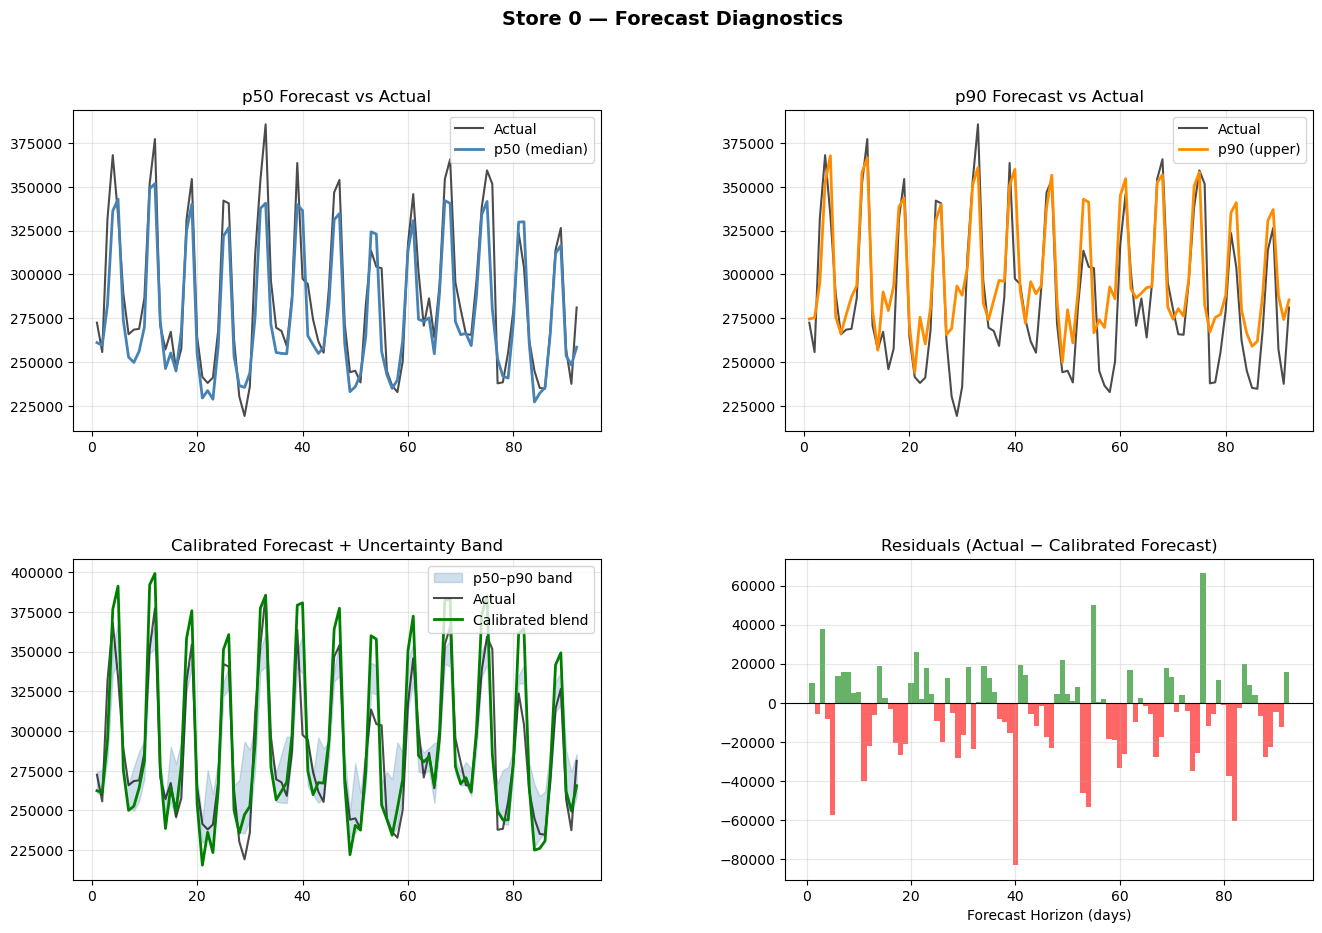


 Training Store: 1
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 2991.63
  RMSE (after calibration): 4397.28


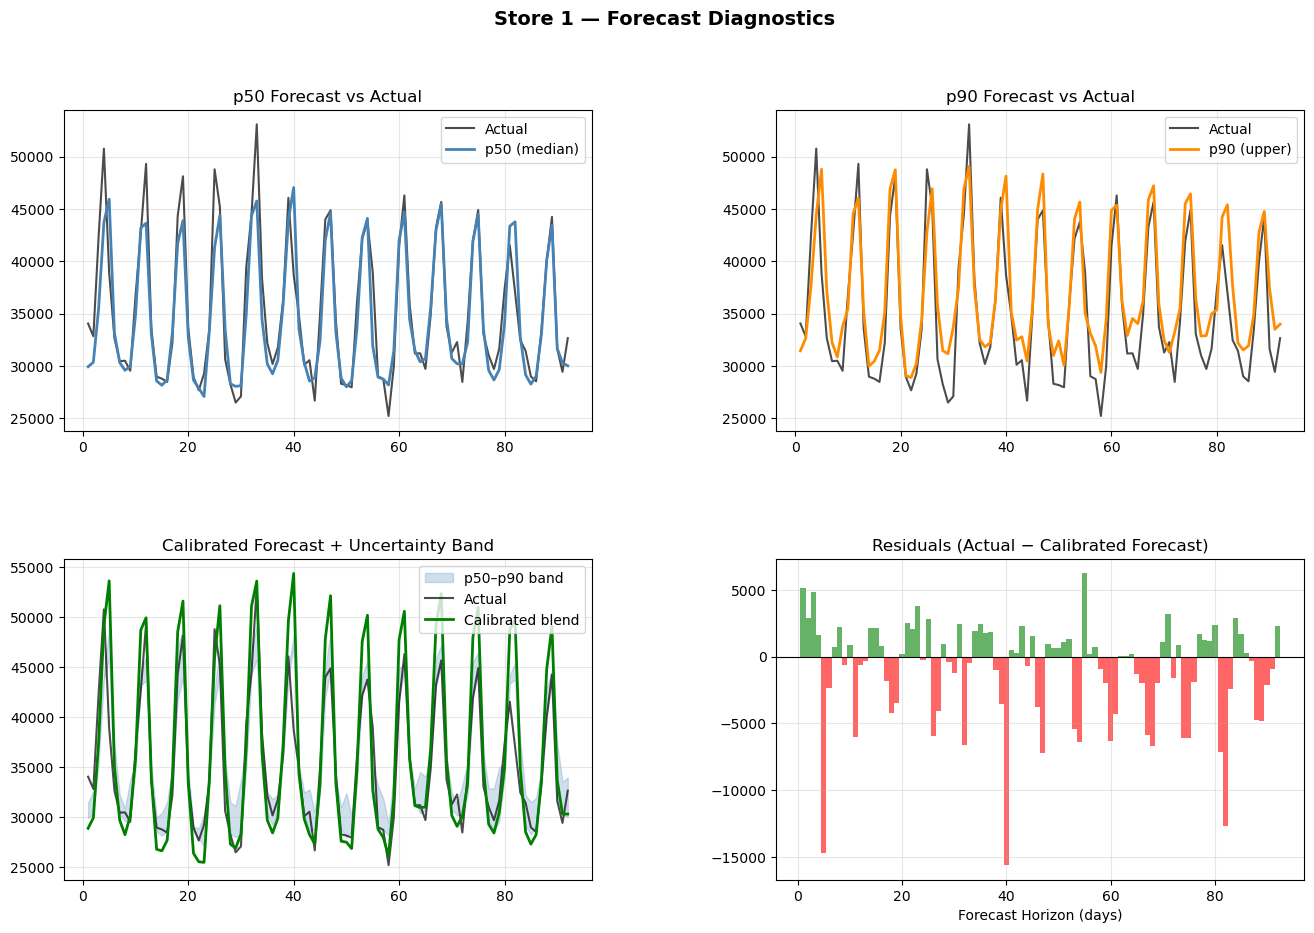


 Training Store: 2
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 6149.21
  RMSE (after calibration): 5203.36


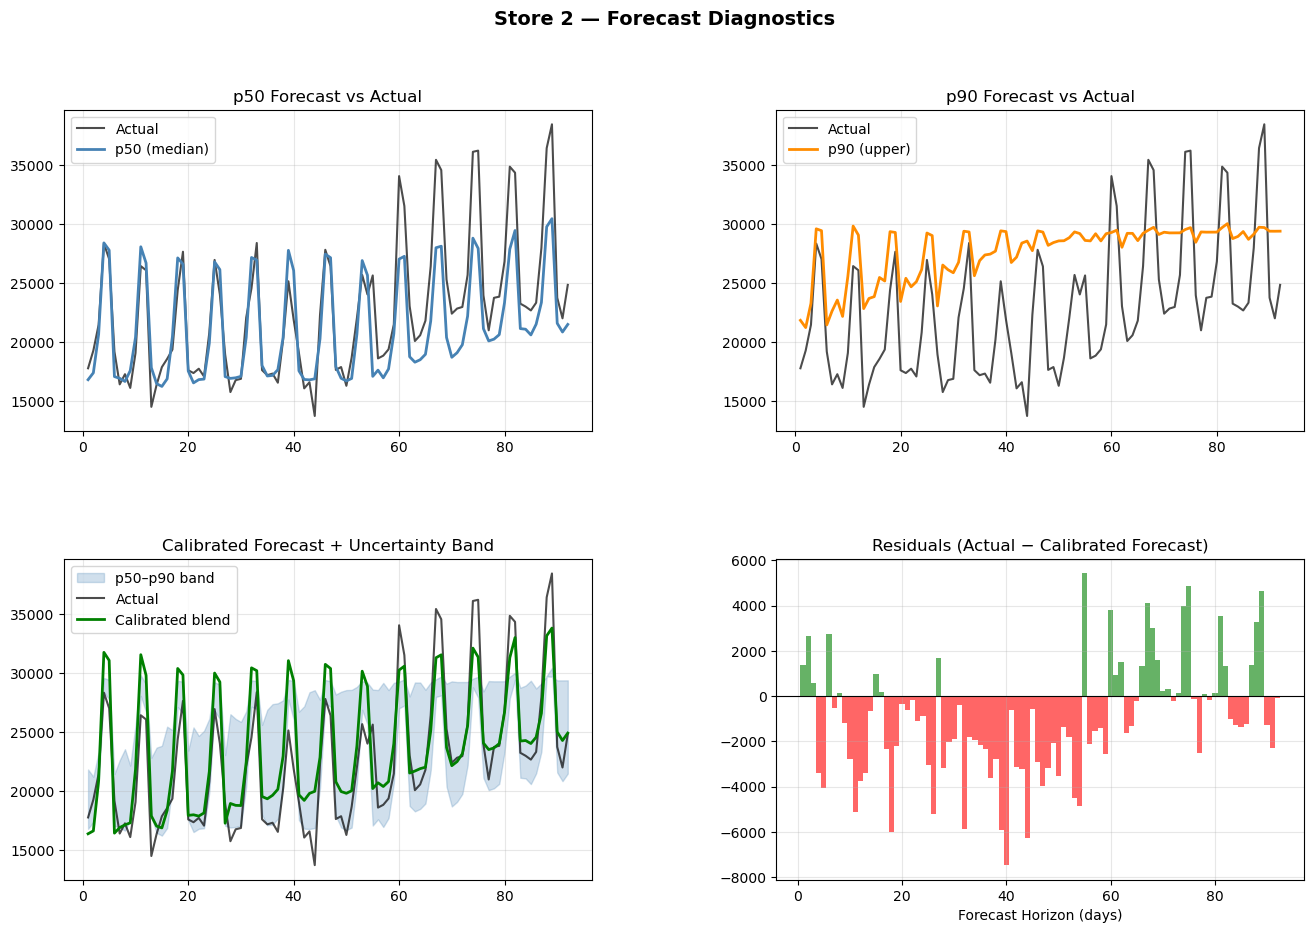


 Training Store: 3
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 3664.30
  RMSE (after calibration): 4858.92


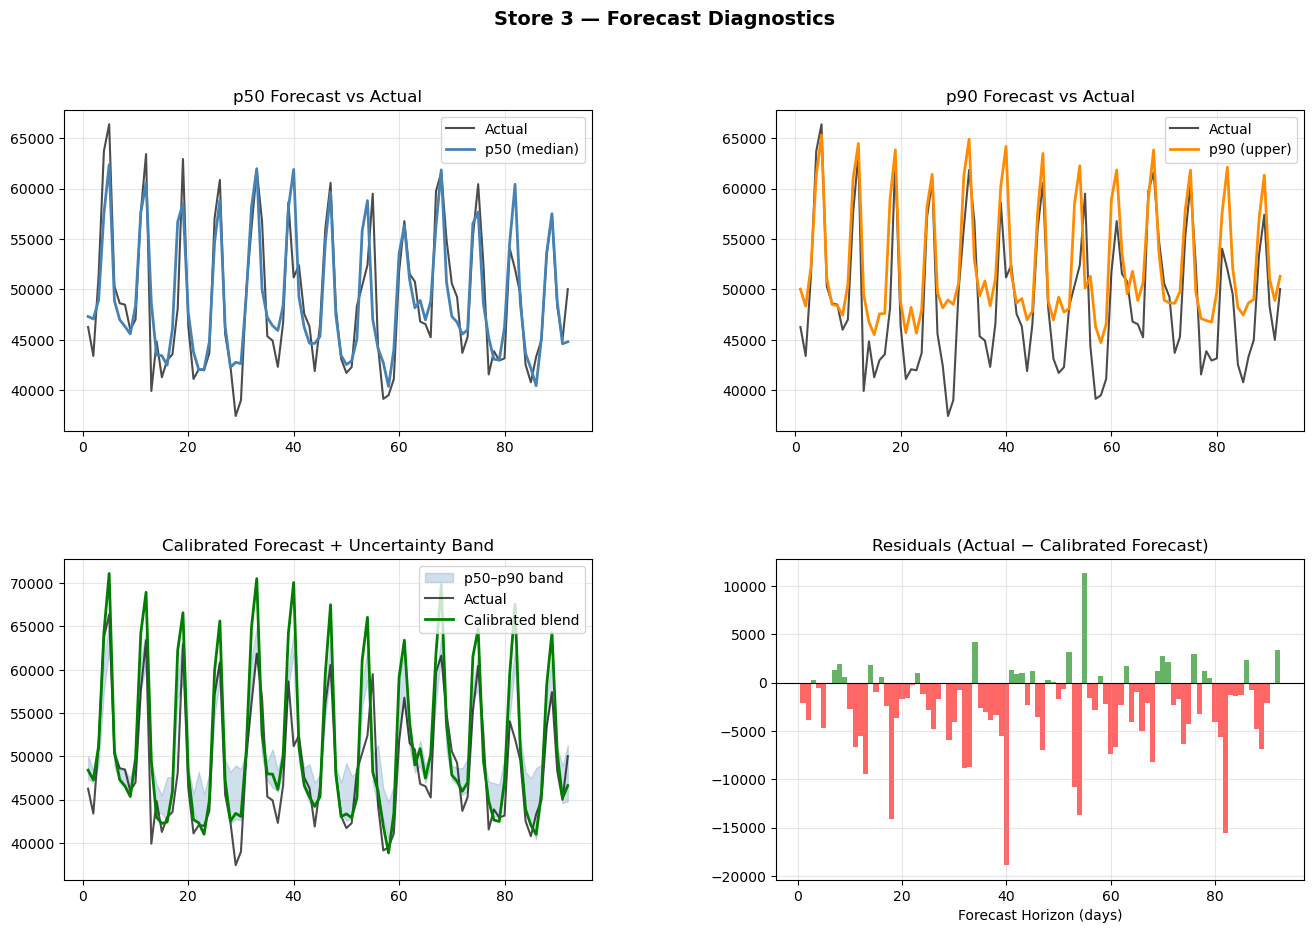


 Training Store: 4
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 1326.26
  RMSE (after calibration): 1514.98


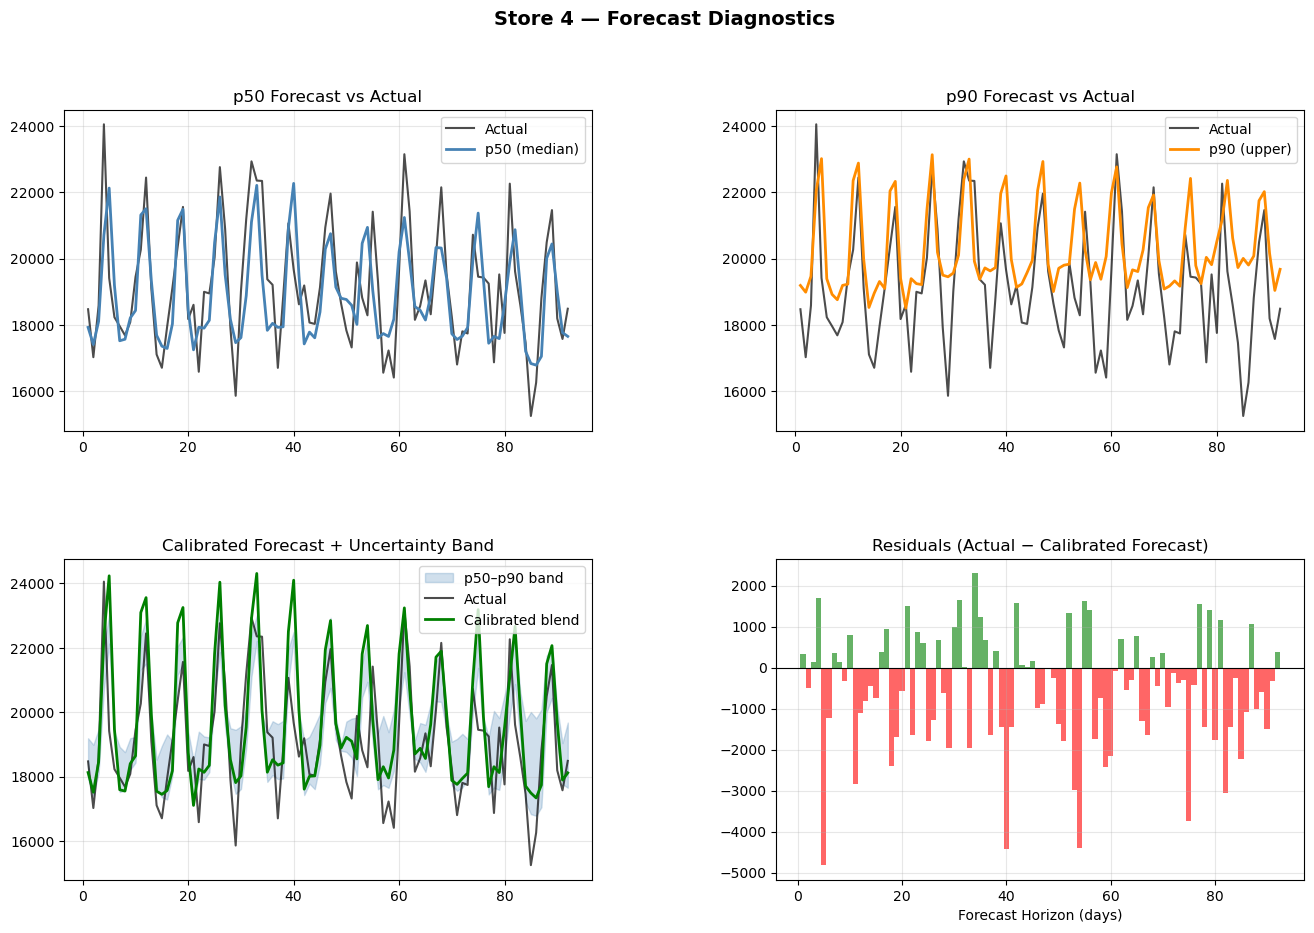


 Training Store: 5
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 2421.87
  RMSE (after calibration): 2610.67


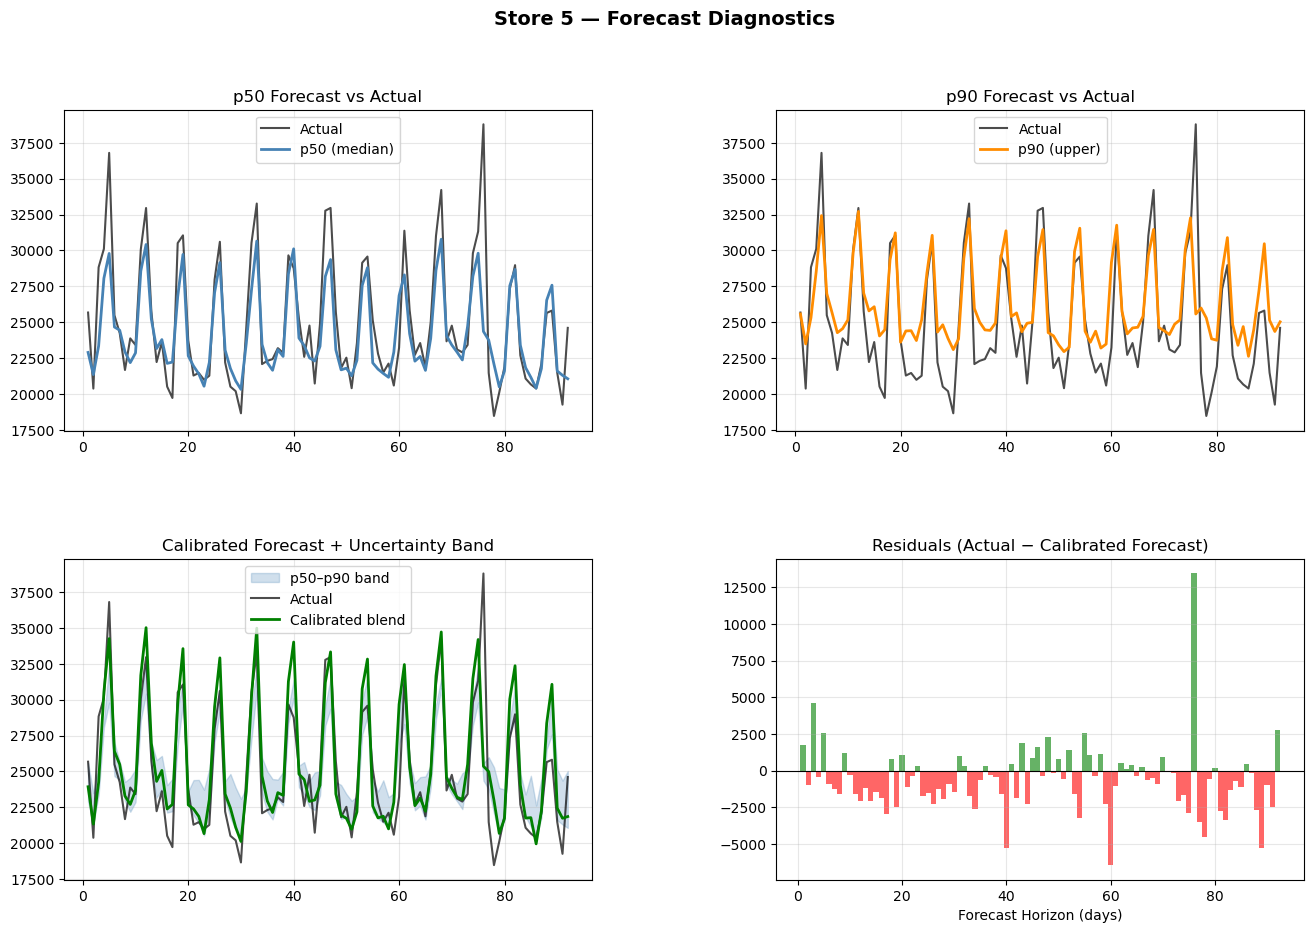


 Training Store: 6
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 3340.95
  RMSE (after calibration): 3954.75


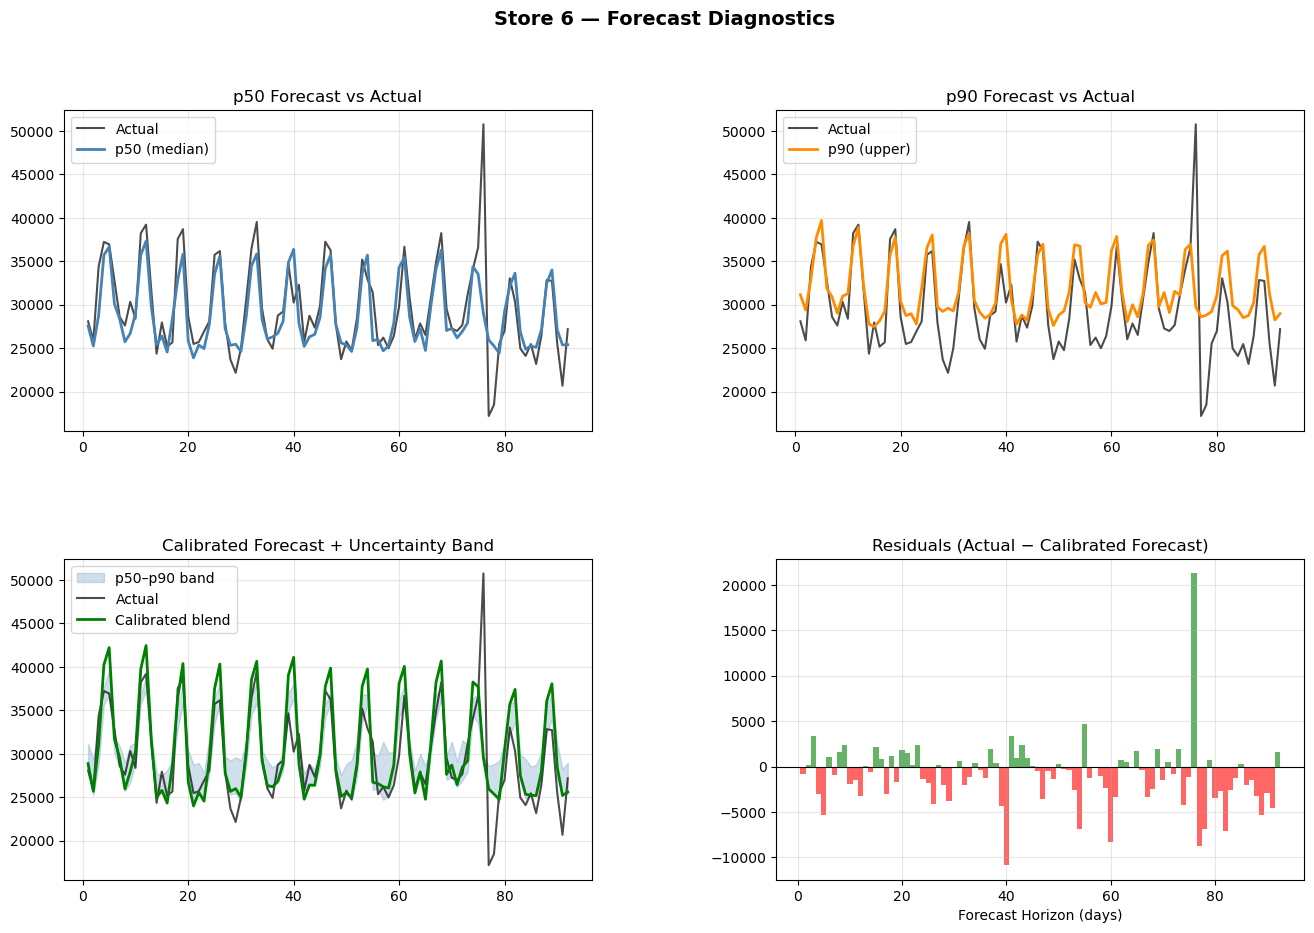


 Training Store: 7
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 3500.18
  RMSE (after calibration): 3400.33


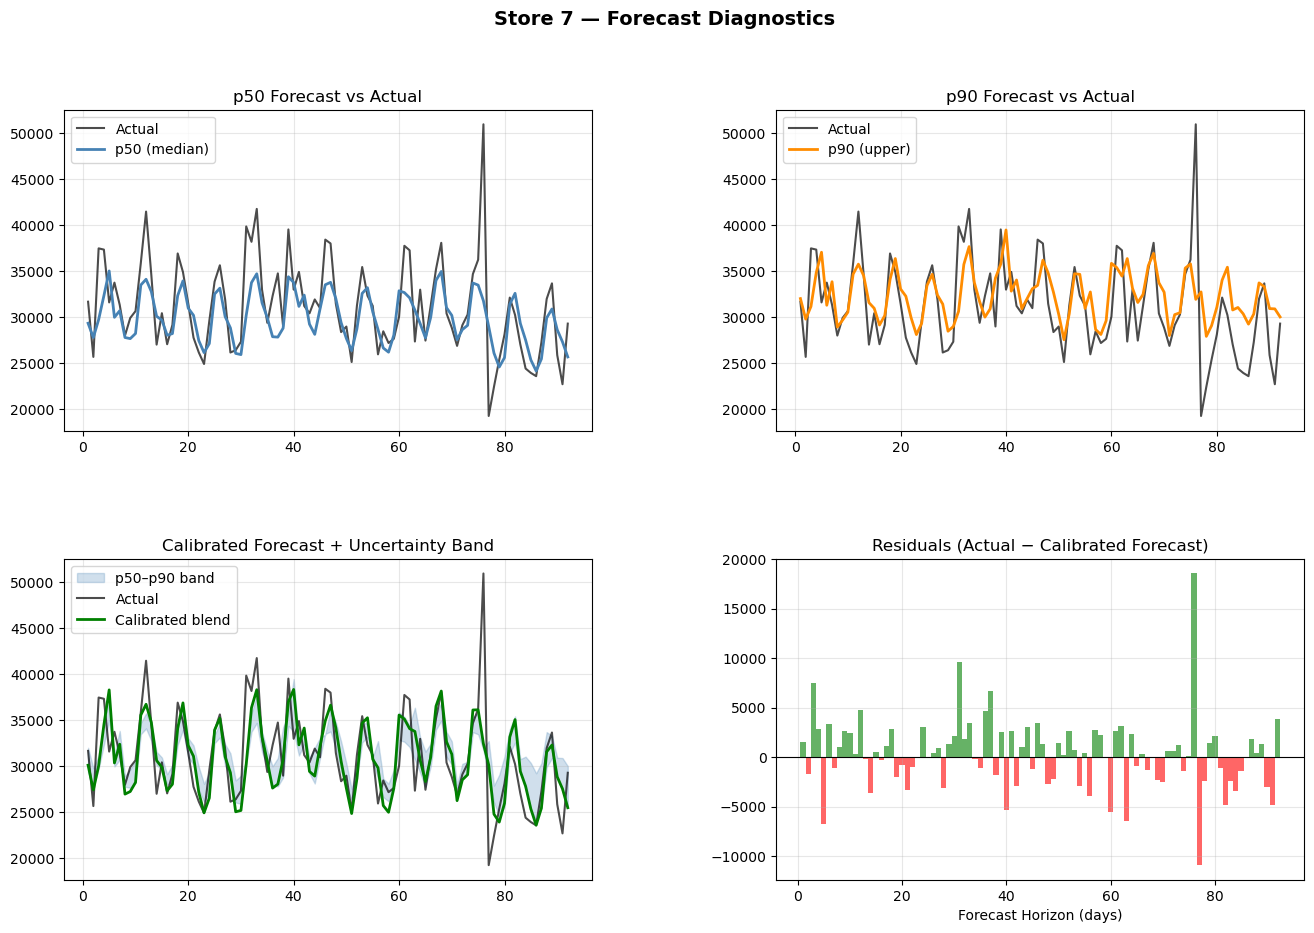


 Training Store: 8
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 2648.55
  RMSE (after calibration): 4260.41


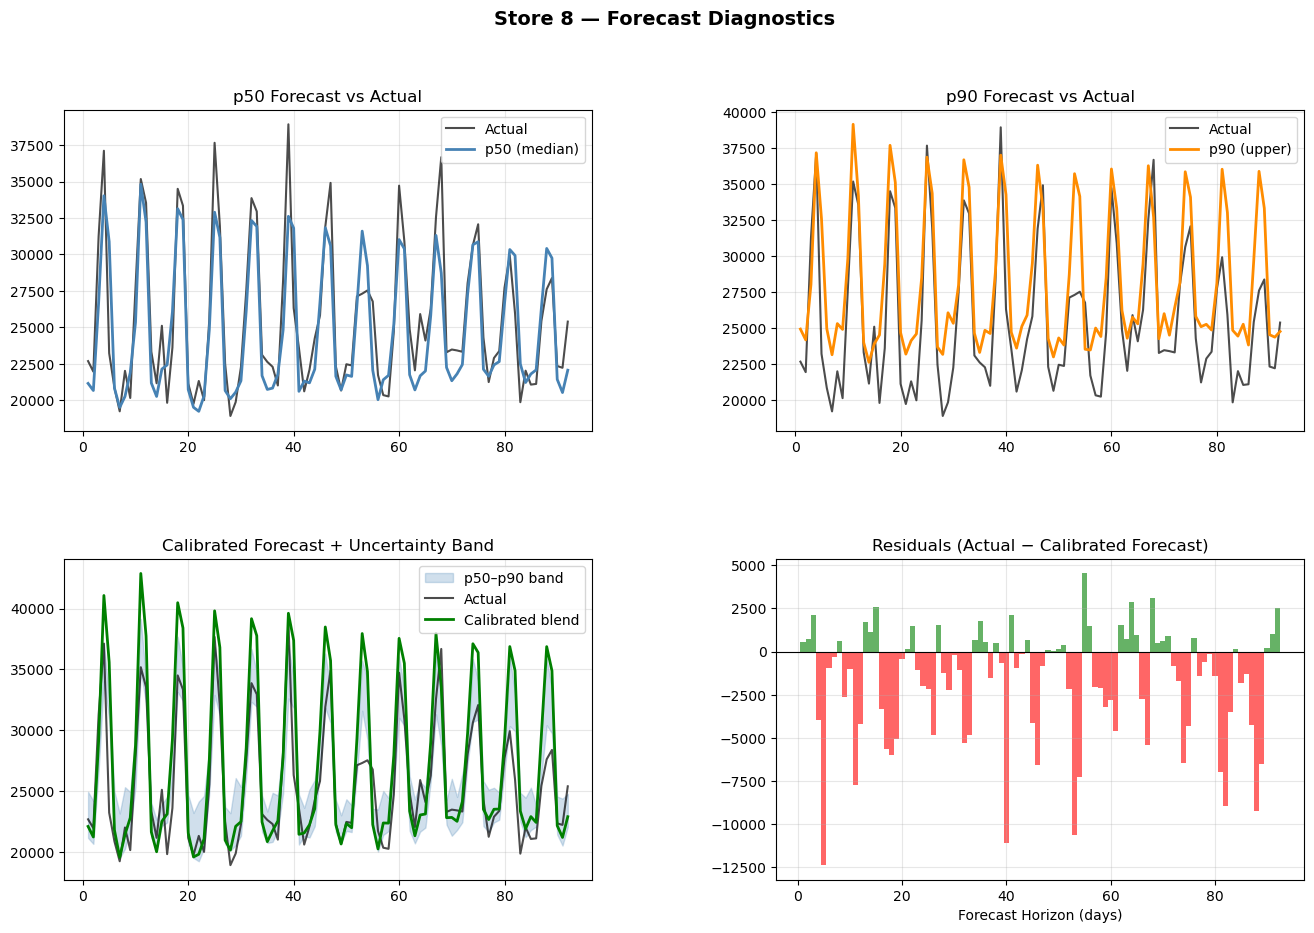


 Training Store: 9
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 2750.69
  RMSE (after calibration): 3286.08


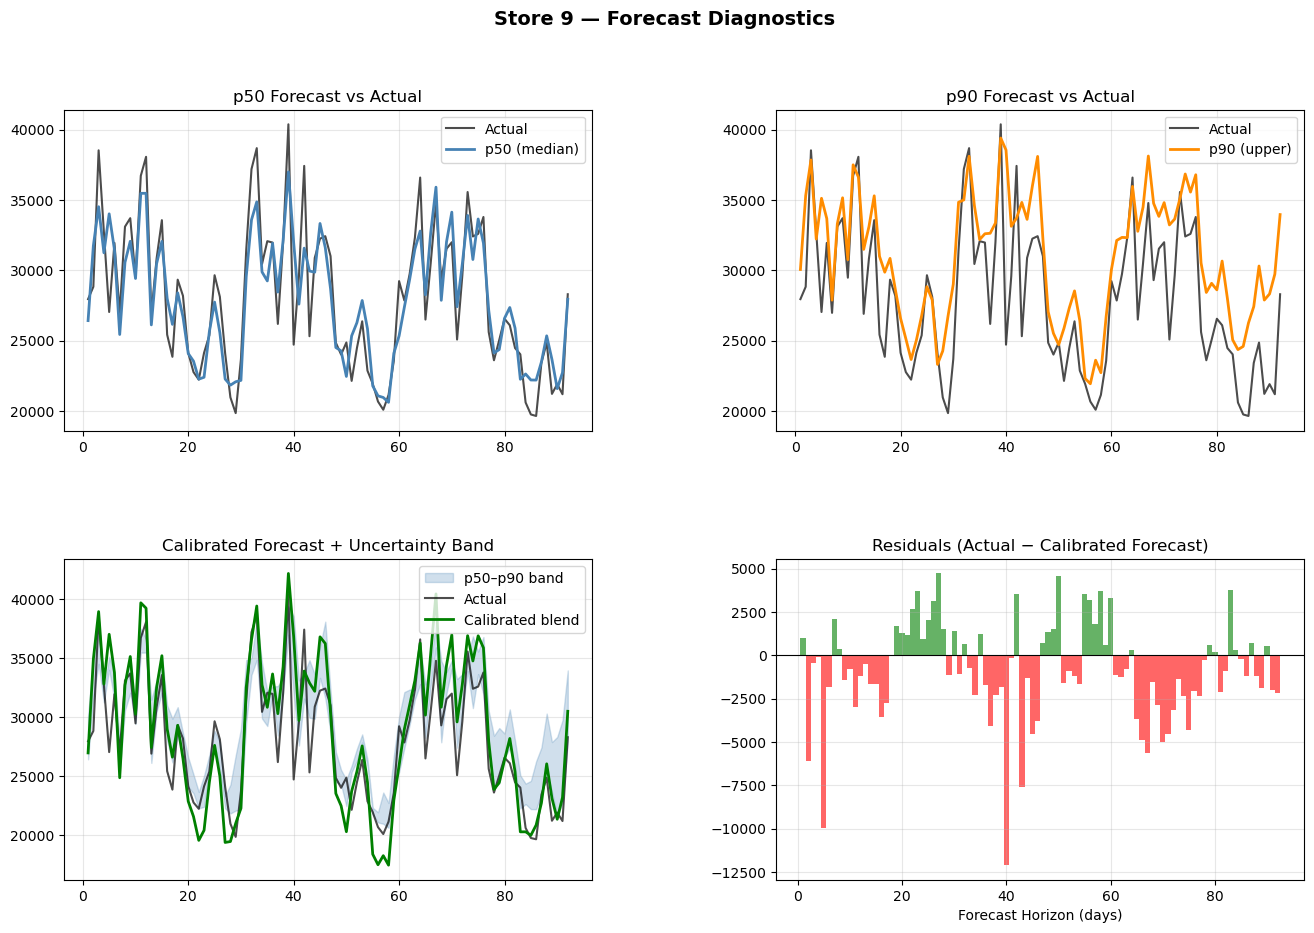


 Training Store: 10
  Trained target day 20/92
  Trained target day 40/92
  Trained target day 60/92
  Trained target day 80/92

  RMSE (blended p50+p90): 2386.92
  RMSE (after calibration): 2837.81


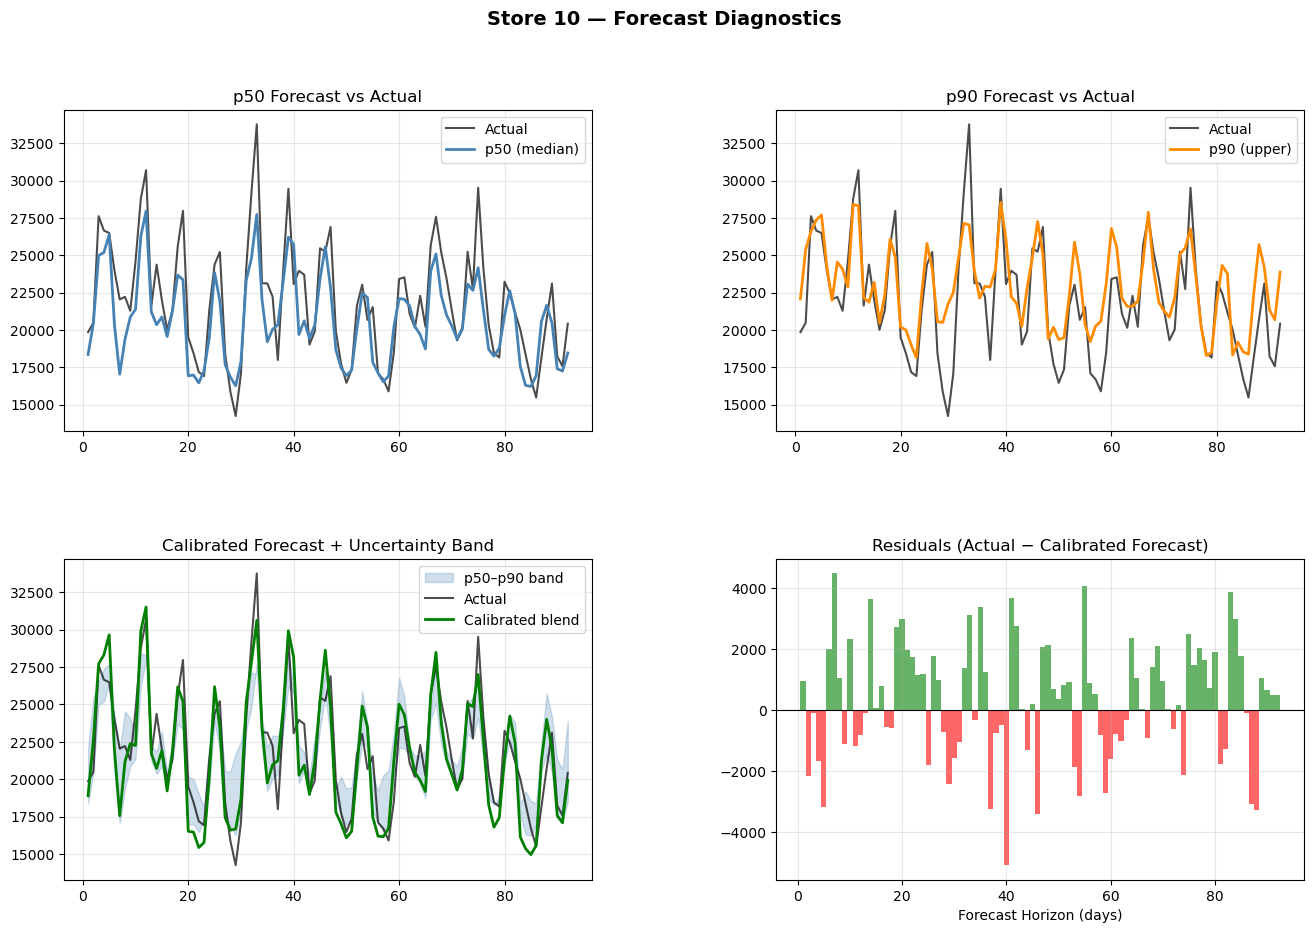


Total Revenue RMSE (all stores, calibrated): 46419.25


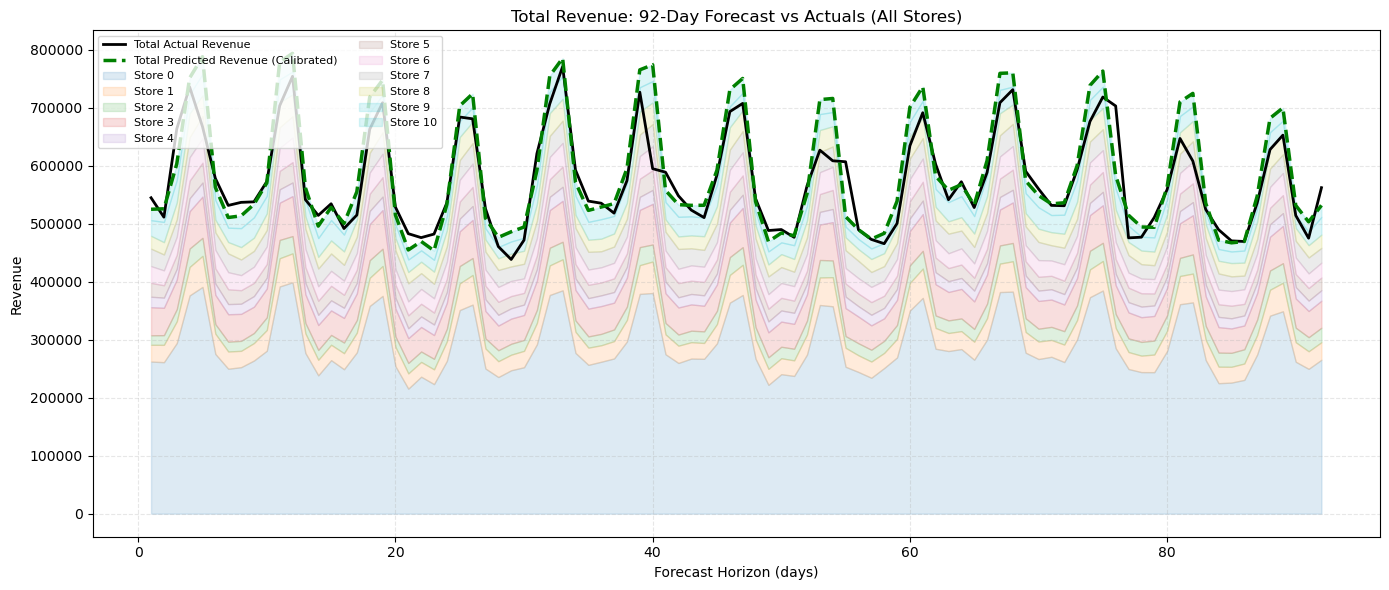

In [5]:
# Feature engineering (same interface as before)
df_features, target_cols = engineer_multioutput_features(df, horizon_days=92, is_training=True)

# Train with quantile blending
store_results = train_multi_output_lgbm(df_features, target_cols, horizon_days=92)

# Aggregate total revenue
total_preds, total_actual = aggregate_total_forecast(store_results, target_cols)

In [8]:
"""
store_forecasting.py
====================
Complete pipeline for multi-store 92-day revenue forecasting with LightGBM.

TWO-STAGE WORKFLOW
------------------
STAGE 1 — Validate  (run once, discard models afterward)
    engineer_multioutput_features(df, is_training=True)
        → drops last 92 days so every row has a complete target matrix
    validate_models(df_val_feat, target_cols)
        → holds out last 92 days per store as a val set
        → prints RMSE, plots predicted vs actual
        → THROW AWAY these models — they're only for checking

STAGE 2 — Production  (run when Stage 1 looks good)
    engineer_multioutput_features(df, is_training=False)
        → keeps ALL rows including the most recent 92 days
    train_production_models(df_prod_feat, target_cols)
        → trains BRAND NEW models on the full dataset
    forecast_future(df_prod_feat, store_models)
        → picks the last row per store → predicts days T+1 … T+92
    export_forecast(forecast_df)
        → saves tidy CSV

HOW TO RUN (copy into your notebook)
--------------------------------------
    import pandas as pd
    from store_forecasting import (
        engineer_multioutput_features,
        validate_models,
        train_production_models,
        forecast_future,
        export_forecast,
    )

    df = pd.read_csv('your_data.csv', parse_dates=['date'])

    # ── STAGE 1: Validate ──────────────────────────────────────────────────
    df_val_feat, target_cols = engineer_multioutput_features(df, is_training=True)
    val_results = validate_models(df_val_feat, target_cols)
    # → inspect the RMSE printout and 4-panel plots per store
    # → if happy, proceed to Stage 2

    # ── STAGE 2: Production ────────────────────────────────────────────────
    df_prod_feat, target_cols = engineer_multioutput_features(df, is_training=False)
    store_models = train_production_models(df_prod_feat, target_cols)
    forecast_df, store_forecasts = forecast_future(df_prod_feat, store_models)
    export_forecast(forecast_df, path='92day_revenue_forecast.csv')
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_squared_error


# ==============================================================================
# SHARED CONSTANTS
# ==============================================================================

LAGS         = [1, 2, 3, 5, 7, 14, 28, 364]
WINDOWS      = [7, 28, 90]
EWM_SPANS    = [7, 28]
BLEND_ALPHA  = 0.35   # weight on p90 — raise toward 0.5 for more aggressive peaks

BASE_PARAMS = dict(
    boosting_type     = 'gbdt',
    learning_rate     = 0.03,
    num_leaves        = 63,
    n_estimators      = 800,
    min_child_samples = 20,
    feature_fraction  = 0.7,
    bagging_fraction  = 0.8,
    bagging_freq      = 5,
    lambda_l1         = 0.1,
    lambda_l2         = 0.1,
    random_state      = 42,
    verbose           = -1,
)

CAT_COLS = ['day_of_week', 'store_id', 'month', 'quarter', 'day_of_month']


# ==============================================================================
# PART 1 — FEATURE ENGINEERING
# ==============================================================================

def engineer_multioutput_features(df, horizon_days=92, is_training=True):
    """
    Build all features and the 92-column target matrix.

    Parameters
    ----------
    df           : raw DataFrame with columns [store_id, date, revenue, event, ...]
    horizon_days : forecast horizon (default 92)
    is_training  : True  → drop tail rows where targets are incomplete (Stage 1)
                   False → keep all rows including the most recent (Stage 2)

    Returns
    -------
    df_cleaned   : feature-engineered DataFrame
    target_cols  : list of target column names ['target_day_1', ..., 'target_day_92']
    """
    df = df.sort_values(['store_id', 'date']).reset_index(drop=True)

    # ------------------------------------------------------------------
    # 1. Calendar features
    # ------------------------------------------------------------------
    df['day_of_week']    = df['date'].dt.dayofweek.astype('category')
    df['day_of_month']   = df['date'].dt.day.astype('category')
    df['month']          = df['date'].dt.month.astype('category')
    df['quarter']        = df['date'].dt.quarter.astype('category')
    df['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend']     = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_month_end']   = df['date'].dt.is_month_end.astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)

    # Cyclical encodings
    day_of_year      = df['date'].dt.dayofyear
    df['day_sin']    = np.sin(2 * np.pi * day_of_year / 365.25)
    df['day_cos']    = np.cos(2 * np.pi * day_of_year / 365.25)
    df['week_sin']   = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['week_cos']   = np.cos(2 * np.pi * df['week_of_year'] / 52)

    # ------------------------------------------------------------------
    # 2. Event features
    #    Lead flags tell the model a spike is COMING (calendar is known)
    # ------------------------------------------------------------------
    df['event']        = df['event'].fillna('None')
    df['is_event']     = (df['event'] != 'None').astype(int)
    df['is_christmas'] = (df['event'] == 'Christmas').astype(int)

    df['event_in_7d'] = (
        df.groupby('store_id')['is_event']
        .transform(lambda x: x.shift(-1).rolling(7,  min_periods=1).max())
        .fillna(0).astype(int)
    )
    df['event_in_14d'] = (
        df.groupby('store_id')['is_event']
        .transform(lambda x: x.shift(-1).rolling(14, min_periods=1).max())
        .fillna(0).astype(int)
    )

    # ------------------------------------------------------------------
    # 3. Lag features
    # ------------------------------------------------------------------
    for lag in LAGS:
        df[f'revenue_lag_{lag}'] = df.groupby('store_id')['revenue'].shift(lag)

    # ------------------------------------------------------------------
    # 4. Rolling window features
    # ------------------------------------------------------------------
    for window in WINDOWS:
        grp = df.groupby('store_id')['revenue']
        df[f'rolling_mean_{window}d'] = grp.transform(lambda x: x.rolling(window, min_periods=1).mean())
        df[f'rolling_std_{window}d']  = grp.transform(lambda x: x.rolling(window, min_periods=1).std())
        df[f'rolling_max_{window}d']  = grp.transform(lambda x: x.rolling(window, min_periods=1).max())
        df[f'rolling_min_{window}d']  = grp.transform(lambda x: x.rolling(window, min_periods=1).min())

    # Exponential weighted mean — reacts faster than plain rolling mean
    for span in EWM_SPANS:
        df[f'ewm_mean_{span}'] = df.groupby('store_id')['revenue'].transform(
            lambda x: x.ewm(span=span, adjust=False).mean()
        )

    # Volatility ratio — flags when the current period is unusually spiky
    df['volatility_ratio_7_28'] = df['rolling_std_7d'] / (df['rolling_std_28d'] + 1e-6)

    # Momentum ratios — trend direction across scales
    df['momentum_7_28']  = df['rolling_mean_7d']  / (df['rolling_mean_28d'] + 1e-6)
    df['momentum_7_90']  = df['rolling_mean_7d']  / (df['rolling_mean_90d'] + 1e-6)
    df['momentum_28_90'] = df['rolling_mean_28d'] / (df['rolling_mean_90d'] + 1e-6)

    # Peak-aware: historical max/mean for this same week of year in prior years
    df['same_week_max_ly']  = df.groupby(['store_id', 'week_of_year'])['revenue'].transform(
        lambda x: x.shift(1).expanding().max()
    )
    df['same_week_mean_ly'] = df.groupby(['store_id', 'week_of_year'])['revenue'].transform(
        lambda x: x.shift(1).expanding().mean()
    )

    # YoY ratio: current 7d mean vs same window one year ago
    df['yoy_ratio'] = (
        df['rolling_mean_7d']
        / (df['revenue_lag_364'].rolling(7, min_periods=1).mean() + 1e-6)
    )

    # ------------------------------------------------------------------
    # 5. Target matrix — 92 forward-looking columns
    # ------------------------------------------------------------------
    target_cols = []
    for lead in range(1, horizon_days + 1):
        col = f'target_day_{lead}'
        df[col] = df.groupby('store_id')['revenue'].shift(-lead)
        target_cols.append(col)

    # ------------------------------------------------------------------
    # 6. Clean up
    # ------------------------------------------------------------------
    df['store_id'] = df['store_id'].astype('category')

    # Always drop the start where historical lags are unavailable
    df_cleaned = df.dropna(subset=[f'revenue_lag_{max(LAGS)}']).reset_index(drop=True)

    # Only in training mode: drop the tail where future targets are unavailable
    if is_training:
        df_cleaned = df_cleaned.dropna(subset=[f'target_day_{horizon_days}']).reset_index(drop=True)

    return df_cleaned, target_cols


# ==============================================================================
# SHARED MODEL TRAINING LOOP
# Used by both validate_models() and train_production_models()
# ==============================================================================

def _train_store_models(X_train, y_train, target_cols, horizon_days,
                        X_val=None, y_val=None, early_stopping=True):
    """
    Trains p50 + p90 LightGBM models for each of the 92 target days.
    If X_val / y_val provided, uses early stopping.
    Returns (models_p50, models_p90, train_amplitude).
    """
    models_p50 = []
    models_p90 = []

    for i, target_col in enumerate(target_cols):
        y_tr = y_train[target_col].values
        dtrain = lgb.Dataset(X_train, label=y_tr)

        callbacks = [lgb.log_evaluation(period=-1)]  # silent

        if early_stopping and X_val is not None:
            y_vl   = y_val[target_col].values
            dval   = lgb.Dataset(X_val, label=y_vl, reference=dtrain)
            valid_sets = [dval]
            callbacks.append(lgb.early_stopping(stopping_rounds=50, verbose=False))
        else:
            valid_sets = []

        # p50 — median (conservative central estimate)
        m50 = lgb.train(
            {**BASE_PARAMS, 'objective': 'quantile', 'alpha': 0.50, 'metric': 'quantile'},
            dtrain,
            num_boost_round=BASE_PARAMS['n_estimators'],
            valid_sets=valid_sets,
            callbacks=callbacks,
        )
        models_p50.append(m50)

        # p90 — upper quantile (recovers peaks)
        m90 = lgb.train(
            {**BASE_PARAMS, 'objective': 'quantile', 'alpha': 0.90, 'metric': 'quantile'},
            dtrain,
            num_boost_round=BASE_PARAMS['n_estimators'],
            valid_sets=valid_sets,
            callbacks=callbacks,
        )
        models_p90.append(m90)

        if (i + 1) % 20 == 0:
            print(f"    Day {i+1}/{horizon_days} trained")

    return models_p50, models_p90


def _blend_and_calibrate(models_p50, models_p90, X, train_amplitude, horizon_days):
    """Predict, blend p50+p90, apply amplitude calibration. Returns (p50, p90, calibrated)."""
    pred_p50 = np.array([m.predict(X) for m in models_p50]).T   # shape (n_rows, horizon)
    pred_p90 = np.array([m.predict(X) for m in models_p90]).T

    pred_blended = (1 - BLEND_ALPHA) * pred_p50 + BLEND_ALPHA * pred_p90

    # Amplitude calibration: scale deviations from median to match historical amplitude
    pred_median    = np.median(pred_blended, axis=1, keepdims=True)
    pred_amplitude = pred_blended.max(axis=1).mean() - pred_median.mean()

    if pred_amplitude > 0:
        scale = min(train_amplitude / pred_amplitude, 1.5)   # cap at 1.5× for safety
        pred_calibrated = pred_median + scale * (pred_blended - pred_median)
    else:
        pred_calibrated = pred_blended

    # Revenue cannot be negative
    pred_p50        = np.clip(pred_p50,        0, None)
    pred_p90        = np.clip(pred_p90,        0, None)
    pred_calibrated = np.clip(pred_calibrated, 0, None)

    return pred_p50, pred_p90, pred_calibrated


# ==============================================================================
# PART 2 — STAGE 1: VALIDATION
# ==============================================================================

def validate_models(df_val_feat, target_cols, horizon_days=92):
    """
    STAGE 1 — Proof of concept validation.

    Splits each store's data chronologically: trains on everything up to
    (max_date - 92 days), validates on the last 92 days.
    Prints RMSE and shows 4-panel diagnostic plots.

    Parameters
    ----------
    df_val_feat  : output of engineer_multioutput_features(df, is_training=True)
    target_cols  : list of target column names

    Returns
    -------
    val_results  : dict per store with preds and actuals (for inspection only)
                   DISCARD after reviewing — do not use for production forecasting.
    """
    drop_cols    = ['date', 'revenue', 'store_name', 'event'] + target_cols
    feature_cols = [col for col in df_val_feat.columns if col not in drop_cols]

    val_results = {}

    for store in df_val_feat['store_id'].unique():
        print(f"\n{'='*55}")
        print(f"  VALIDATION — Store: {store}")
        print(f"{'='*55}")

        store_df   = df_val_feat[df_val_feat['store_id'] == store].copy()
        max_date   = store_df['date'].max()
        split_date = max_date - pd.Timedelta(days=horizon_days)

        train_mask = store_df['date'] <= split_date
        val_mask   = store_df['date'] >  split_date

        X_train = store_df.loc[train_mask, feature_cols]
        y_train = store_df.loc[train_mask, target_cols]
        X_val   = store_df.loc[val_mask,   feature_cols]
        y_val   = store_df.loc[val_mask,   target_cols]

        if len(X_val) == 0:
            print(f"  Skipping — not enough data for a validation split.")
            continue

        _cast_cats(X_train, X_val, feature_cols)

        train_amplitude = (store_df.loc[train_mask, 'revenue'].max()
                           - store_df.loc[train_mask, 'revenue'].median())

        print(f"  Training on {len(X_train)} rows, validating on {len(X_val)} rows...")
        models_p50, models_p90 = _train_store_models(
            X_train, y_train, target_cols, horizon_days,
            X_val=X_val, y_val=y_val, early_stopping=True
        )

        pred_p50, pred_p90, pred_calibrated = _blend_and_calibrate(
            models_p50, models_p90, X_val, train_amplitude, horizon_days
        )

        y_val_arr = y_val.values
        rmse_p50  = np.sqrt(mean_squared_error(y_val_arr, pred_p50))
        rmse_cal  = np.sqrt(mean_squared_error(y_val_arr, pred_calibrated))
        print(f"\n  RMSE p50             : {rmse_p50:.2f}")
        print(f"  RMSE calibrated blend: {rmse_cal:.2f}")

        _plot_store_diagnostics(store, y_val_arr, pred_p50, pred_p90,
                                pred_calibrated, horizon_days)

        val_results[store] = {
            'pred_p50'       : pred_p50,
            'pred_p90'       : pred_p90,
            'pred_calibrated': pred_calibrated,
            'actual'         : y_val_arr,
        }

    # Aggregate validation total
    _plot_validation_total(val_results, horizon_days)

    print("\n✓ Validation complete. Review plots and RMSE above.")
    print("  If results look good → run Stage 2 (train_production_models).")
    return val_results


# ==============================================================================
# PART 3 — STAGE 2a: PRODUCTION TRAINING
# ==============================================================================

def train_production_models(df_prod_feat, target_cols, horizon_days=92):
    """
    STAGE 2 — Train brand new models on the COMPLETE dataset.

    No validation split here — uses every row including the most recent 92 days
    that were held out during validation. This gives the model maximum signal
    for forecasting the true future.

    Parameters
    ----------
    df_prod_feat : output of engineer_multioutput_features(df, is_training=False)
    target_cols  : list of target column names

    Returns
    -------
    store_models : dict passed directly into forecast_future()
    """
    drop_cols    = ['date', 'revenue', 'store_name', 'event'] + target_cols
    feature_cols = [col for col in df_prod_feat.columns if col not in drop_cols]

    store_models = {}

    for store in df_prod_feat['store_id'].unique():
        print(f"\n{'='*55}")
        print(f"  PRODUCTION TRAINING — Store: {store}")
        print(f"{'='*55}")

        store_df = df_prod_feat[df_prod_feat['store_id'] == store].copy()

        # Drop rows where the target matrix is NaN (the very last rows —
        # these are used for inference, not for training)
        store_df_train = store_df.dropna(subset=target_cols).copy()

        X_all = store_df_train[feature_cols].copy()
        y_all = store_df_train[target_cols]

        _cast_cats(X_all, feature_cols=feature_cols)

        train_amplitude = (store_df_train['revenue'].max()
                           - store_df_train['revenue'].median())

        print(f"  Training on {len(X_all)} rows (full history, no holdout)...")

        # No validation set → no early stopping; use full n_estimators
        models_p50, models_p90 = _train_store_models(
            X_all, y_all, target_cols, horizon_days,
            X_val=None, y_val=None, early_stopping=False
        )

        store_models[store] = {
            'models_p50'     : models_p50,
            'models_p90'     : models_p90,
            'feature_cols'   : feature_cols,
            'train_amplitude': train_amplitude,
        }

    print("\n✓ Production training complete.")
    return store_models


# ==============================================================================
# PART 4 — STAGE 2b: INFERENCE
# ==============================================================================

def forecast_future(df_prod_feat, store_models, horizon_days=92):
    """
    STAGE 2 — Generate the true future 92-day forecast.

    Picks the last available row per store (day T) and runs all 92 models
    to produce a forward-looking forecast for T+1 … T+92.

    Parameters
    ----------
    df_prod_feat : output of engineer_multioutput_features(df, is_training=False)
                   (same DataFrame passed to train_production_models)
    store_models : dict returned by train_production_models()

    Returns
    -------
    forecast_df      : tidy DataFrame [store_id, forecast_origin, forecast_date,
                        day_ahead, pred_p50, pred_p90, pred_calibrated]
    all_forecasts    : dict per store with raw arrays (for plotting)
    """
    records       = []
    all_forecasts = {}

    for store, bundle in store_models.items():
        print(f"\nForecasting Store: {store}")

        store_df     = df_prod_feat[df_prod_feat['store_id'] == store].copy()
        feature_cols = bundle['feature_cols']

        _cast_cats(store_df, feature_cols=feature_cols)

        # Last row = most recent day T with all lag/rolling features populated
        last_row        = store_df.iloc[[-1]]
        forecast_origin = pd.Timestamp(last_row['date'].values[0])
        X_infer         = last_row[feature_cols]

        print(f"  Origin : {forecast_origin.date()}")
        print(f"  Covers : {(forecast_origin + pd.Timedelta(days=1)).date()} → "
              f"{(forecast_origin + pd.Timedelta(days=horizon_days)).date()}")

        pred_p50, pred_p90, pred_calibrated = _blend_and_calibrate(
            bundle['models_p50'], bundle['models_p90'],
            X_infer, bundle['train_amplitude'], horizon_days
        )

        # Squeeze from (1, 92) → (92,) for convenience
        pred_p50        = pred_p50[0]
        pred_p90        = pred_p90[0]
        pred_calibrated = pred_calibrated[0]

        all_forecasts[store] = {
            'forecast_origin': forecast_origin,
            'pred_p50'       : pred_p50,
            'pred_p90'       : pred_p90,
            'pred_calibrated': pred_calibrated,
        }

        for day_ahead in range(1, horizon_days + 1):
            records.append({
                'store_id'       : store,
                'forecast_origin': forecast_origin,
                'forecast_date'  : forecast_origin + pd.Timedelta(days=day_ahead),
                'day_ahead'      : day_ahead,
                'pred_p50'       : pred_p50[day_ahead - 1],
                'pred_p90'       : pred_p90[day_ahead - 1],
                'pred_calibrated': pred_calibrated[day_ahead - 1],
            })

    forecast_df = pd.DataFrame(records)

    _plot_future_per_store(all_forecasts, horizon_days)
    _plot_future_total(all_forecasts, horizon_days)

    return forecast_df, all_forecasts


# ==============================================================================
# PART 5 — EXPORT
# ==============================================================================

def export_forecast(forecast_df, path='92day_revenue_forecast.csv'):
    """Save forecast to CSV and print a preview."""
    forecast_df.to_csv(path, index=False)
    print(f"\n✓ Forecast saved → {path}")
    print(f"  Rows : {len(forecast_df):,}")
    print(f"  Stores : {forecast_df['store_id'].nunique()}")
    print(f"  Date range : {forecast_df['forecast_date'].min().date()} → "
          f"{forecast_df['forecast_date'].max().date()}")
    print("\nPreview:")
    print(forecast_df.head(10).to_string(index=False))
    return forecast_df


# ==============================================================================
# INTERNAL HELPERS
# ==============================================================================

def _cast_cats(*dfs, feature_cols=None):
    """Cast known categorical columns in-place. Accepts 1 or 2 DataFrames."""
    cols = CAT_COLS if feature_cols is None else [c for c in CAT_COLS if c in feature_cols]
    for df in dfs:
        if isinstance(df, pd.DataFrame):
            for col in cols:
                if col in df.columns:
                    df[col] = df[col].astype('category')


# ==============================================================================
# PLOTS — VALIDATION
# ==============================================================================

def _plot_store_diagnostics(store, y_val_arr, pred_p50, pred_p90,
                             pred_calibrated, horizon_days):
    """4-panel diagnostic plot for one store during validation."""
    days      = np.arange(1, horizon_days + 1)
    actual    = y_val_arr[0]
    p50       = pred_p50[0]
    p90       = pred_p90[0]
    cal       = pred_calibrated[0]
    residuals = actual - cal

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f"Store {store} — Validation Diagnostics", fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(days, actual, color='black', alpha=0.7, label='Actual')
    ax1.plot(days, p50,    color='steelblue', lw=2,   label='p50')
    ax1.set_title('p50 vs Actual'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(days, actual, color='black', alpha=0.7,  label='Actual')
    ax2.plot(days, p90,    color='darkorange', lw=2,  label='p90')
    ax2.set_title('p90 vs Actual'); ax2.legend(); ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.fill_between(days, p50, p90, alpha=0.25, color='steelblue', label='p50–p90 band')
    ax3.plot(days, actual, color='black', alpha=0.7, label='Actual')
    ax3.plot(days, cal,    color='green', lw=2,     label='Calibrated blend')
    ax3.set_title('Calibrated Forecast + Uncertainty Band')
    ax3.legend(); ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.bar(days, residuals, color=np.where(residuals >= 0, 'green', 'red'), alpha=0.6, width=1.0)
    ax4.axhline(0, color='black', lw=0.8)
    ax4.set_title('Residuals (Actual − Calibrated)')
    ax4.set_xlabel('Forecast Horizon (days)'); ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()


def _plot_validation_total(val_results, horizon_days):
    """Aggregate all stores' validation predictions into a total revenue plot."""
    if not val_results:
        return
    stores    = list(val_results.keys())
    days      = np.arange(1, horizon_days + 1)
    total_act = sum(val_results[s]['actual'][0]         for s in stores)
    total_cal = sum(val_results[s]['pred_calibrated'][0] for s in stores)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(days, total_act, color='black', lw=2,      label='Total Actual')
    ax.plot(days, total_cal, color='green', lw=2.5, linestyle='--', label='Total Calibrated')
    ax.set_title('Validation — Total Revenue (All Stores)')
    ax.set_xlabel('Forecast Horizon (days)'); ax.set_ylabel('Revenue')
    ax.legend(); ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout(); plt.show(); plt.close()


# ==============================================================================
# PLOTS — PRODUCTION FORECAST (no actuals)
# ==============================================================================

def _plot_future_per_store(all_forecasts, horizon_days):
    """Grid of per-store future forecasts with uncertainty band."""
    stores  = list(all_forecasts.keys())
    n_cols  = 3
    n_rows  = int(np.ceil(len(stores) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    fig.suptitle("Production Forecast — Per Store (92 Days)", fontsize=14, fontweight='bold', y=1.01)

    for idx, store in enumerate(stores):
        ax  = axes[idx // n_cols][idx % n_cols]
        res = all_forecasts[store]
        dates = pd.date_range(start=res['forecast_origin'] + pd.Timedelta(days=1),
                              periods=horizon_days, freq='D')

        ax.fill_between(dates, res['pred_p50'], res['pred_p90'],
                        alpha=0.2, color='steelblue', label='p50–p90 band')
        ax.plot(dates, res['pred_p50'],        color='steelblue',  lw=1.5, linestyle='--', label='p50')
        ax.plot(dates, res['pred_p90'],        color='darkorange', lw=1.5, linestyle='--', label='p90')
        ax.plot(dates, res['pred_calibrated'], color='green',      lw=2.0, label='Calibrated')
        ax.set_title(f"Store {store}\n(from {res['forecast_origin'].date()})", fontsize=9)
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3, linestyle='--')

    for idx in range(len(stores), n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    plt.tight_layout(); plt.show(); plt.close()


def _plot_future_total(all_forecasts, horizon_days):
    """Stacked total revenue production forecast — 2 panels."""
    stores    = list(all_forecasts.keys())
    origin    = all_forecasts[stores[0]]['forecast_origin']
    dates     = pd.date_range(start=origin + pd.Timedelta(days=1), periods=horizon_days, freq='D')
    total_p50 = sum(all_forecasts[s]['pred_p50']        for s in stores)
    total_p90 = sum(all_forecasts[s]['pred_p90']        for s in stores)
    total_cal = sum(all_forecasts[s]['pred_calibrated'] for s in stores)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle("Production Forecast — Total Revenue (All Stores)", fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.fill_between(dates, total_p50, total_p90, alpha=0.2, color='steelblue', label='p50–p90 band')
    ax.plot(dates, total_p50, color='steelblue',  lw=1.5, linestyle='--', label='Total p50')
    ax.plot(dates, total_p90, color='darkorange', lw=1.5, linestyle='--', label='Total p90')
    ax.plot(dates, total_cal, color='green',      lw=2.5,                 label='Total Calibrated')
    ax.set_ylabel('Total Revenue'); ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--'); ax.tick_params(axis='x', rotation=30)

    ax2     = axes[1]
    cmap    = plt.cm.tab10
    bottom  = np.zeros(horizon_days)
    for j, store in enumerate(stores):
        contrib = all_forecasts[store]['pred_calibrated']
        ax2.fill_between(dates, bottom, bottom + contrib,
                         alpha=0.55, color=cmap(j % 10), label=f'Store {store}')
        bottom += contrib
    ax2.set_ylabel('Revenue (stacked)'); ax2.set_xlabel('Forecast Date')
    ax2.legend(fontsize=8, ncol=3, loc='upper left')
    ax2.grid(True, alpha=0.3, linestyle='--'); ax2.tick_params(axis='x', rotation=30)

    plt.tight_layout(); plt.show(); plt.close()

In [ ]:
df_val_feat, target_cols = engineer_multioutput_features(df, is_training=True)
val_results = validate_models(df_val_feat, target_cols)

/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_77688/2008254707.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_77688/2008254707.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_77688/2008254707.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usual


  Full-data training — Store: 0
  Target day 20/92 done
  Target day 40/92 done
  Target day 60/92 done
  Target day 80/92 done

  Full-data training — Store: 1
  Target day 20/92 done
  Target day 40/92 done
  Target day 60/92 done
  Target day 80/92 done

  Full-data training — Store: 2
  Target day 20/92 done
  Target day 40/92 done
  Target day 60/92 done
  Target day 80/92 done

  Full-data training — Store: 3
  Target day 20/92 done
  Target day 40/92 done
  Target day 60/92 done
  Target day 80/92 done

  Full-data training — Store: 4
  Target day 20/92 done
  Target day 40/92 done
  Target day 60/92 done
  Target day 80/92 done

  Full-data training — Store: 5
  Target day 20/92 done
  Target day 40/92 done
  Target day 60/92 done
  Target day 80/92 done

  Full-data training — Store: 6
  Target day 20/92 done


KeyboardInterrupt: 

In [ ]:
df_prod_feat, target_cols = engineer_multioutput_features(df, is_training=False)
store_models  = train_production_models(df_prod_feat, target_cols)
forecast_df, store_forecasts = forecast_future(df_prod_feat, store_models)
export_forecast(forecast_df, path='92day_revenue_forecast.csv')

/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_77688/2640233477.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_77688/2640233477.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = df.groupby('store_id')['revenue'].shift(-lead)
/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_77688/2640233477.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res


  PRODUCTION TRAINING — Store: 0
  Training on 1250 rows (full history, no holdout)...
    Day 20/92 trained
    Day 40/92 trained
    Day 60/92 trained
    Day 80/92 trained

  PRODUCTION TRAINING — Store: 1
  Training on 1250 rows (full history, no holdout)...
    Day 20/92 trained
    Day 40/92 trained
    Day 60/92 trained
    Day 80/92 trained

  PRODUCTION TRAINING — Store: 2
  Training on 1250 rows (full history, no holdout)...
    Day 20/92 trained
    Day 40/92 trained
    Day 60/92 trained
    Day 80/92 trained

  PRODUCTION TRAINING — Store: 3
  Training on 1250 rows (full history, no holdout)...
    Day 20/92 trained
    Day 40/92 trained
    Day 60/92 trained
    Day 80/92 trained
